In [1]:
import json
import os
import warnings
from itertools import combinations

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygeohash as pgh
import seaborn as sns
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

/home/aniket/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# CELL 2 -- Constants, paths, ward/regional groupings, analysis parameters, plotting settings


def _find_repo_root():
    here = os.getcwd()
    for candidate in (here, os.path.join(here, ".."), os.path.join(here, "..", "..")):
        candidate = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(candidate, "data")) and os.path.isdir(os.path.join(candidate, "analysis")):
            return candidate
    raise RuntimeError("Could not locate repo root (expected sibling data/ and analysis/ dirs).")


REPO_ROOT = _find_repo_root()
DATA = os.path.join(REPO_ROOT, "data")
print(f"Repo root resolved to: {REPO_ROOT}")

# ---- census inputs -------------------------------------------------------
WARD_CENSUS_CSV = os.path.join(DATA, "census", "wards", "toronto-wards.csv")
WARD_NOC_NAICS_CSV = os.path.join(DATA, "census", "wards", "toronto-wards-noc-naics.csv")
WARD_GEOJSON = os.path.join(DATA, "geo", "city-wards.geojson")

# ---- activity / mobility inputs ------------------------------------------
ACTIVITY_DIR = os.path.join(DATA, "activity")
VENUE_STOPS_CSV = os.path.join(ACTIVITY_DIR, "venue_stops.csv")
VENUES_HOMES_CSV = os.path.join(ACTIVITY_DIR, "venues_homes.csv")
VENUE_METRICS_JSON = os.path.join(ACTIVITY_DIR, "venue_metrics.json")

WARDS_ACTIVITY_DIR = os.path.join(ACTIVITY_DIR, "wards")
WARD_TO_VENUE_ACTIVITY_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_venue_activity.csv")
WARD_TO_VENUE_SUMMARY_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_venue_summary.csv")
WARD_TO_WARD_ACTIVITY_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_ward_activity.csv")
WARD_TO_WARD_SUMMARY_CSV = os.path.join(WARDS_ACTIVITY_DIR, "ward_to_ward_summary.csv")

# ---- venue / location inventories ----------------------------------------
VENUE_CENTROIDS_GEOJSON = os.path.join(DATA, "venues", "tac-list", "venues-centroids.geojson")
BROADER_INVENTORY_CSV = os.path.join(DATA, "venues", "tac-list", "current_toronto_arts_locations_eddit.csv")

# ---- analysis parameters ---------------------------------------------------
TIME_PERIOD = "all"  # headline results always use the undivided "all" time period -- see Section 1
VALUE_COL = "normalized_raw_stop_count_by_ward"  # ward-mapped, sample-normalized activity metric used throughout
MERIDIAN_VENUE_NAMES = ["Meridian Arts Centre"]
MATCH_TOLERANCE_M = 75  # coordinate-match tolerance between the 105-venue sample and the broader inventory (Section 4)
GEOHASH6_PRECISION = 6

# ---- ward -> region classification (consistent with Story 1) --------------
# City of Toronto's four Community Council areas -- documented, citable, and gives a
# natural "alternative downtown boundary" for sensitivity checks (Section 6).
WARD_REGION = {
    "Etobicoke North": "Etobicoke York", "Etobicoke Centre": "Etobicoke York",
    "Etobicoke-Lakeshore": "Etobicoke York", "York South-Weston": "Etobicoke York",
    "York Centre": "Etobicoke York", "Humber River-Black Creek": "Etobicoke York",
    "Eglinton-Lawrence": "Etobicoke York",
    "Parkdale-High Park": "Toronto and East York", "Davenport": "Toronto and East York",
    "Spadina-Fort York": "Toronto and East York", "University-Rosedale": "Toronto and East York",
    "Toronto-St. Paul's": "Toronto and East York", "Toronto Centre": "Toronto and East York",
    "Toronto-Danforth": "Toronto and East York", "Beaches-East York": "Toronto and East York",
    "Don Valley West": "North York", "Don Valley East": "North York",
    "Don Valley North": "North York", "Willowdale": "North York",
    "Scarborough Southwest": "Scarborough", "Scarborough Centre": "Scarborough",
    "Scarborough-Agincourt": "Scarborough", "Scarborough North": "Scarborough",
    "Scarborough-Guildwood": "Scarborough", "Scarborough-Rouge Park": "Scarborough",
}
SCARBOROUGH_WARDS = [w for w, r in WARD_REGION.items() if r == "Scarborough"]
SUBURBAN_REGIONS = ["Etobicoke York", "North York", "Scarborough"]
ALL_REGIONS = ["Toronto and East York"] + SUBURBAN_REGIONS

DOWNTOWN_CORE_WARDS_BROAD = [w for w, r in WARD_REGION.items() if r == "Toronto and East York"]
DOWNTOWN_CORE_WARDS_NARROW = [w for w in DOWNTOWN_CORE_WARDS_BROAD if w != "Beaches-East York"]


def region_of(ward, downtown_wards=DOWNTOWN_CORE_WARDS_BROAD):
    return "Downtown/core" if ward in downtown_wards else WARD_REGION[ward]


# ---- the five custom cultural-workforce measures ---------------------------
# Never summed -- they slice on different, overlapping axes (occupation / industry / field
# of study). See Section 2 for the full definitions and the "which is closest to 'artists'"
# discussion, which we work out from the data dictionary rather than assuming an answer.
NOC_NAICS_MEASURES = [
    "labour_creatives", "labour_cultural_workers", "labour_cultural_industries",
    "labour_independent_artists", "labour_arts_major",
]
NOC_NAICS_LABELS = {
    "labour_creatives": "Creatives (NOC occupation)",
    "labour_cultural_workers": "Cultural workers (NOC occupation, broader)",
    "labour_cultural_industries": "Cultural industries (NAICS industry, broader)",
    "labour_independent_artists": "Independent artists & arts orgs (NAICS industry)",
    "labour_arts_major": "Arts-major education (CIP field of study)",
}
NOC_NAICS_BASIS = {
    "labour_creatives": "occupation", "labour_cultural_workers": "occupation",
    "labour_cultural_industries": "industry", "labour_independent_artists": "industry",
    "labour_arts_major": "field_of_study",
}
# Preferred single measures for headline framing (a documented choice, justified in Section 2 --
# not an assumption): occupation-based measures answer "what job does this person do", which is
# the most direct definitional match for "artist"/"cultural worker"; industry- and education-based
# measures are kept as complementary, narrower or broader lenses, never substituted silently.
ARTIST_MEASURE = "labour_creatives"           # primary "artists" proxy (occupation-based)
ARTIST_MEASURE_ALT = "labour_independent_artists"  # narrower, industry-based artist proxy (self-employed/freelance angle)
WORKFORCE_MEASURE = "labour_cultural_workers"      # primary "broader cultural workforce" proxy
ARTS_TRAINED_MEASURE = "labour_arts_major"         # arts-trained residents (education), not necessarily working in the arts

# ---- known candidate mismatch wards from the earlier notebook -- treated as hypotheses to
# test with the broader inventory and mobility data here, not as required conclusions.
CANDIDATE_MISMATCH_WARDS_TO_TEST = [
    "Eglinton-Lawrence", "Don Valley West", "Willowdale", "Don Valley North", "Scarborough Southwest",
]

# ---- a small, hypothesis-led set of general ward-census characteristics for Section 9 ------
GENERAL_CENSUS_CHARACTERISTICS = {
    "income_total_median": "Median total income, 2020 ($)",
    "housing_tenure_renter": "Renter households (count)",
    "housing_tenure_total": "Total private households (renter-share denominator)",
    "housing_shelter_30plus": "Households spending 30%+ of income on shelter costs (count)",
    "housing_shelter_total": "Total households w/ income > 0 (shelter-cost-burden denominator)",
    "pop_density": "Population density (per km^2)",
    "age_median": "Median age",
    "education_bachelor_higher": "Bachelor's degree or higher, age 15+ (count)",
    "education_total": "Total, age 15+ (education-share denominator)",
    "citizen_not_canadian": "Not Canadian citizens (count)",
    "citizen_total": "Total, citizenship universe (denominator)",
    "visible_minority_yes": "Visible minority population (count)",
    "visible_minority_total": "Total, visible-minority universe (denominator)",
    "commute_mode_transit": "Commutes mainly by public transit (count)",
    "commute_mode_total": "Total commuters (transit-share denominator)",
    "commute_duration_60plus": "Commute 60+ minutes (count)",
    "commute_duration_total": "Total commuters (long-commute-share denominator)",
}

# ---- broader-inventory ordinal categories ---------------------------------
FUNDING_FREQ_ORDER = ["rare", "low", "mid", "high", "very_high"]
FREE_PROG_ORDER = ["none", "rare", "low", "mid", "high", "very_high"]

# ---- plotting ---------------------------------------------------------------
PALETTE = sns.color_palette("colorblind")
REGION_COLORS = dict(zip(ALL_REGIONS, PALETTE))
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
tqdm.pandas()

Repo root resolved to: /home/aniket/Programming/eddit-tac


# Story 2: Toronto's cultural workforce already lives across the city -- has infrastructure kept pace?

**Audience:** the Toronto Arts Council (TAC) board (citywide distribution, funding and
infrastructure strategy) and city councillors (their ward's resident cultural workforce, the
infrastructure currently present, and where their residents already use included venues).

**Central question, treated as a hypothesis to test, not a conclusion to assume:**

> Are there parts of Toronto where a meaningful resident cultural workforce already exists,
> but the local cultural infrastructure visible in our data has not kept pace?

The earlier notebook (`explore_census_activity_data.ipynb`) found that cultural-worker
concentration and venue provision are *positively* related citywide -- so if there is a story
here, it is more likely about **specific exception wards** than a general citywide mismatch.
This notebook re-derives that finding from scratch (it does not assume it), brings in the
broader ~2,576-location inventory (not just the 105-venue mobility sample) and the residents'
venue-activity data, and ends with a concrete data-story outline. This notebook is
self-contained: it does not depend on any variable from another notebook.

## 1. Establish the analytical frame

Three different kinds of evidence are combined in this notebook, and they measure genuinely
different things:

1. **Resident cultural workforce** (`toronto-wards-noc-naics.csv`) -- custom StatCan NOC
   (occupation), NAICS (industry) and CIP (field-of-study) tabulations, describing **where
   these residents live**, not where they work, perform, or spend time.
2. **Cultural infrastructure** -- the broader ~2,576-location inventory
   (`current_toronto_arts_locations_eddit.csv`, presence of locations, not their size,
   quality, capacity, discipline or level of activity) and the smaller 105-venue mobility
   *study sample* (which has activity data attached, but is not exhaustive).
3. **Resident venue activity** (`data/activity/`) -- normalized mobility-derived activity
   linking home wards to the 105 sample venues. This is **not** attendance, unique people, or
   a percentage of residents participating, and it does not identify individuals.

Caveats preserved throughout the notebook:

- A relationship between a ward's cultural workforce and its residents' venue activity is
  **ecological** -- it describes wards, not individuals, and cannot show that the cultural
  workers themselves visited those venues.
- The broader inventory measures **presence**, not size or quality; `TAC_funded_activities`
  and `funding_frequency` do not measure funding dollars or demonstrate a funding effect.
- Ward boundaries are political/analytical units and may not correspond to cultural
  communities or natural catchments.
- We never sum the five workforce measures -- they are different, overlapping definitions,
  not additive components of one total.

In [3]:
# --- load the resident cultural-workforce file ------------------------------
ward_noc_naics = pd.read_csv(WARD_NOC_NAICS_CSV, dtype={"ward_code": str})
ward_noc_naics["ward_code"] = ward_noc_naics["ward_code"].str.zfill(2)
ward_noc_naics["region"] = ward_noc_naics["ward_name"].map(WARD_REGION)
assert ward_noc_naics.shape[0] == 25 and ward_noc_naics["region"].notna().all()

# --- load the general ward census file (long form) -------------------------
census_long = pd.read_csv(WARD_CENSUS_CSV, dtype={"ward_code": str}, encoding="latin1")
census_long["ward_code"] = census_long["ward_code"].str.zfill(2)
pop_row = census_long[census_long["CHARACTERISTIC_CODE"] == "pop_2021"]
ward_pop = pop_row[["ward_code", "ward_name", "C1_COUNT_TOTAL"]].rename(columns={"C1_COUNT_TOTAL": "population_2021_allages"})
ward_pop["region"] = ward_pop["ward_name"].map(WARD_REGION)
assert ward_pop.shape[0] == 25 and ward_pop["ward_code"].is_unique and ward_pop["region"].notna().all()

# --- load ward flow / activity tables (same renames as Story 1) ------------
ward_to_venue_activity = pd.read_csv(WARD_TO_VENUE_ACTIVITY_CSV).rename(columns={
    "ward_name": "origin_ward", "venue_ward": "dest_ward", "home_ward": "is_home_ward",
})
ward_to_venue_summary = pd.read_csv(WARD_TO_VENUE_SUMMARY_CSV).rename(columns={"home_ward": "dest_ward"})
ward_to_ward_activity = pd.read_csv(WARD_TO_WARD_ACTIVITY_CSV).rename(columns={"ward_name": "origin_ward", "venue_ward": "dest_ward"})
ward_to_ward_summary = pd.read_csv(WARD_TO_WARD_SUMMARY_CSV).rename(columns={"ward_name": "origin_ward"})

# --- load authoritative ward geometry, resolve a metric CRS -----------------
wards_gdf_raw = gpd.read_file(WARD_GEOJSON)
wards_gdf = wards_gdf_raw[wards_gdf_raw.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
assert wards_gdf.shape[0] == 25
if wards_gdf.crs is None:
    wards_gdf = wards_gdf.set_crs("EPSG:4326")
UTM_CRS = wards_gdf.estimate_utm_crs()
print(f"estimated UTM CRS for metric distance work: {UTM_CRS}")

# --- venue metadata (coordinates, ward assignment, TAC funding flags) ------
with open(VENUE_CENTROIDS_GEOJSON) as f:
    _centroids = json.load(f)
venue_meta = pd.json_normalize([f["properties"] | {"lon": f["geometry"]["coordinates"][0],
                                                     "lat": f["geometry"]["coordinates"][1]}
                                 for f in _centroids["features"]])
venue_meta["venue_id"] = venue_meta["id"].astype(int)
venue_meta = venue_meta.drop(columns=["id", "fid"])
assert venue_meta["venue_id"].nunique() == 105

venue_to_dest_ward = ward_to_venue_activity.loc[ward_to_venue_activity["is_home_ward"], ["venue_id", "venue_name", "dest_ward"]].drop_duplicates()
assert venue_to_dest_ward["venue_id"].is_unique

venue_points = gpd.GeoDataFrame(
    venue_meta[["venue_id", "venue_name", "lat", "lon"]],
    geometry=gpd.points_from_xy(venue_meta["lon"], venue_meta["lat"]), crs="EPSG:4326",
)
venue_ward_spatial = gpd.sjoin(venue_points, wards_gdf[["ward_name", "geometry"]], predicate="within")[["venue_id", "ward_name"]].rename(columns={"ward_name": "dest_ward_spatial"})
_check = venue_to_dest_ward.merge(venue_ward_spatial, on="venue_id", how="left")
_mismatch = (_check["dest_ward"] != _check["dest_ward_spatial"]).sum()
print(f"venue-ward assignment verified spatially: {_mismatch} mismatches out of {len(_check)} venues")

print(f"\nward_noc_naics: {ward_noc_naics.shape}  |  ward_pop: {ward_pop.shape}  |  venue_meta: {venue_meta.shape}")

estimated UTM CRS for metric distance work: EPSG:32617


venue-ward assignment verified spatially: 0 mismatches out of 105 venues

ward_noc_naics: (25, 14)  |  ward_pop: (25, 4)  |  venue_meta: (105, 18)


In [4]:
# --- condensed QA, reusing the earlier notebooks' established checks -------
# 1. all 25 wards present and keyed consistently across the two census files
assert set(ward_noc_naics["ward_name"]) == set(ward_pop["ward_name"]) == set(wards_gdf["ward_name"])

# 2. self-consistency: the file's own published pct fields reproduce from pop_2021_count
#    (its own age-15+ universe denominator) -- confirms the denominator, does not assume it
max_pct_diff = 0.0
for m in NOC_NAICS_MEASURES:
    recomputed = 100 * ward_noc_naics[f"{m}_count"] / ward_noc_naics["pop_2021_count"]
    max_pct_diff = max(max_pct_diff, (recomputed - ward_noc_naics[f"{m}_pct"]).abs().max())
assert max_pct_diff < 0.1, "published pct fields don't reproduce from pop_2021_count"
print(f"NOC/NAICS pct fields reproduce from count / pop_2021_count (age 15+ universe) to within {max_pct_diff:.3f} pp")

# 3. population-universe comparison: pop_2021_count (age 15+) vs. general census pop_2021 (all ages)
pop_compare = ward_pop[["ward_name", "population_2021_allages"]].merge(
    ward_noc_naics[["ward_name", "pop_2021_count"]], on="ward_name")
ratio = pop_compare["pop_2021_count"].sum() / pop_compare["population_2021_allages"].sum()
print(f"citywide ratio, NOC/NAICS (age 15+) universe / general census (all ages) population: {ratio:.1%}")

# 4. missingness in both census files
noc_naics_nulls = ward_noc_naics.isna().sum().loc[lambda s: s > 0]
print(f"\nNOC/NAICS file nulls per column: {'none' if noc_naics_nulls.empty else noc_naics_nulls.to_dict()}")
gen_nulls = census_long.loc[census_long['CHARACTERISTIC_CODE'].isin(GENERAL_CENSUS_CHARACTERISTICS), 'C1_COUNT_TOTAL'].isna().sum()
print(f"general census file nulls among the {len(GENERAL_CENSUS_CHARACTERISTICS)} selected characteristics: {gen_nulls}")

# 5. dense cross-join + within/outside reconciliation on the activity tables (same as Story 1)
assert ward_to_venue_activity.shape[0] == ward_to_venue_activity["venue_id"].nunique() * 25
agg_check = ward_to_ward_activity.groupby(["origin_ward", "same_ward"], as_index=False)[VALUE_COL].sum()
within = agg_check[agg_check["same_ward"]].set_index("origin_ward")[VALUE_COL]
outside = agg_check[~agg_check["same_ward"]].groupby("origin_ward")[VALUE_COL].sum()
recon = ward_to_ward_summary.set_index("origin_ward")
assert (recon["normalized_raw_stop_count_within_ward"] - within).abs().max() < 1e-6
assert (recon["normalized_raw_stop_count_outside_ward"] - outside).abs().max() < 1e-6
print("\nActivity-table QA passed: dense cross-join confirmed, within/outside totals reconcile.")
print("No time_period column on any ward_to_* activity table -> pre-built at time_period == 'all' only.")

NOC/NAICS pct fields reproduce from count / pop_2021_count (age 15+ universe) to within 0.050 pp
citywide ratio, NOC/NAICS (age 15+) universe / general census (all ages) population: 84.5%

NOC/NAICS file nulls per column: none
general census file nulls among the 17 selected characteristics: 0

Activity-table QA passed: dense cross-join confirmed, within/outside totals reconcile.
No time_period column on any ward_to_* activity table -> pre-built at time_period == 'all' only.


**Findings.** All three data families join cleanly on the same 25 ward names (no fuzzy
matching needed), the NOC/NAICS file's own percentages reproduce exactly from its stated age
15+ population base, and the activity tables reconcile the same way they did in Story 1.
There is no missingness in either census file for the fields used here.

**Takeaways.** We can build ward-level comparisons across all three data families with
confidence in the joins. The workforce measures describe an age-15+ population that is
somewhat smaller than each ward's all-ages population (roughly four-fifths citywide) -- worth
remembering when we compare "workforce count" to "all-ages population" elsewhere.

**Story implications.** None of the usual caveats (ecological interpretation, presence vs.
size of infrastructure, activity vs. attendance) are resolved by this QA -- they are
structural properties of the data and are restated at each place they matter below.

## 2. The five cultural-workforce measures

| Measure | Basis | What it actually counts |
|---|---|---|
| `labour_creatives` | NOC occupation | People whose **occupation** is a creative one (e.g. actor, musician, author, visual artist), regardless of employer or industry |
| `labour_cultural_workers` | NOC occupation (broader) | A broader occupational group including creative occupations plus adjacent cultural-sector roles (e.g. technical, instructional, administrative) |
| `labour_cultural_industries` | NAICS industry (broader) | People employed in the broader cultural-**industry** sector (e.g. publishing, broadcasting, heritage institutions, performing-arts companies), regardless of their specific job |
| `labour_independent_artists` | NAICS industry | People employed specifically in the "independent artists, writers & performers" **industry** class -- close to a self-employed/freelance-artist proxy |
| `labour_arts_major` | CIP field of study | Residents whose highest **educational credential** is in an arts field -- arts-*trained*, not necessarily currently working in the arts |

All five use the same population universe for their `_pct` fields: `pop_2021_count`, each
ward's age-15-and-over resident population from this custom file (verified above to reproduce
the published percentages exactly). Counts are fractional because they are small-area
statistical estimates (custom tabulation, likely built from a survey-weighted or modelled
source), not literal head-counts.

**Which is closest to "artists" specifically?** Two candidates, from two different angles:
`labour_creatives` (occupation -- what job the person actually does) and
`labour_independent_artists` (industry -- works in a business whose core activity is being an
independent artist). We adopt **`labour_creatives`** as the primary "artists" proxy, because
occupation is the more direct definitional match (an actor employed by a large institution is
still an actor), and keep `labour_independent_artists` as a narrower, complementary lens on
self-employed/freelance-style artists specifically.

**Which is the most appropriate "broader cultural workforce" measure?** **`labour_cultural_workers`**
(the broader NOC occupation group) -- it is occupation-based like the preferred artists
measure, so the two stay comparable, and it captures the wider cultural-sector workforce
(technicians, administrators, instructors) beyond just performers/creators.

**`labour_cultural_industries`** (broader NAICS) and **`labour_arts_major`** (CIP) are kept as
useful contrasts, not substitutes: the former captures the cultural *economy* (including
non-creative jobs at cultural employers), the latter captures arts-*trained* residents who may
work anywhere. The five measures are never summed.

In [5]:
# --- citywide totals and shares by measure ----------------------------------
summary_rows = []
for m in NOC_NAICS_MEASURES:
    total = ward_noc_naics[f"{m}_count"].sum()
    summary_rows.append({
        "measure": NOC_NAICS_LABELS[m], "basis": NOC_NAICS_BASIS[m],
        "citywide_count": total, "citywide_mean_pct": ward_noc_naics[f"{m}_pct"].mean(),
        "ward_pct_min": ward_noc_naics[f"{m}_pct"].min(), "ward_pct_max": ward_noc_naics[f"{m}_pct"].max(),
    })
measure_summary = pd.DataFrame(summary_rows)
print("Citywide scale and range of ward concentration, by measure (never summed across rows):")
measure_summary.round(2)

Citywide scale and range of ward concentration, by measure (never summed across rows):


,measure,basis,citywide_count,citywide_mean_pct,ward_pct_min,ward_pct_max
0,Creatives (NOC occupation),occupation,45648.26,1.88,0.4,4.6
1,"Cultural workers (NOC occupation, broader)",occupation,76249.22,3.16,0.7,7.5
2,"Cultural industries (NAICS industry, broader)",industry,60673.48,2.53,0.6,6.3
3,Independent artists & arts orgs (NAICS industry),industry,17435.58,0.72,0.0,2.1
4,Arts-major education (CIP field of study),field_of_study,124621.69,5.21,1.8,10.8


In [6]:
# --- per-ward citywide-share and rank for each measure -----------------------
for m in NOC_NAICS_MEASURES:
    ward_noc_naics[f"{m}_citywide_share"] = ward_noc_naics[f"{m}_count"] / ward_noc_naics[f"{m}_count"].sum()
    ward_noc_naics[f"{m}_rank_count"] = ward_noc_naics[f"{m}_count"].rank(ascending=False, method="min").astype(int)
    ward_noc_naics[f"{m}_rank_pct"] = ward_noc_naics[f"{m}_pct"].rank(ascending=False, method="min").astype(int)
    ward_noc_naics[f"{m}_rank_gap_count_vs_pct"] = ward_noc_naics[f"{m}_rank_pct"] - ward_noc_naics[f"{m}_rank_count"]

print(f"Example -- {NOC_NAICS_LABELS[ARTIST_MEASURE]}, top 5 wards by absolute count:")
cols = ["ward_name", "region", f"{ARTIST_MEASURE}_count", f"{ARTIST_MEASURE}_pct", f"{ARTIST_MEASURE}_citywide_share", f"{ARTIST_MEASURE}_rank_count", f"{ARTIST_MEASURE}_rank_pct"]
ward_noc_naics.sort_values(f"{ARTIST_MEASURE}_count", ascending=False)[cols].head(5).round(3)

Example -- Creatives (NOC occupation), top 5 wards by absolute count:


,ward_name,region,labour_creatives_count,labour_creatives_pct,labour_creatives_citywide_share,labour_creatives_rank_count,labour_creatives_rank_pct
9,Spadina-Fort York,Toronto and East York,5176.593,4.0,0.113,1,4
8,Davenport,Toronto and East York,4276.465,4.6,0.094,2,1
3,Parkdale-High Park,Toronto and East York,4011.710,4.5,0.088,3,2
10,University-Rosedale,Toronto and East York,3915.530,4.3,0.086,4,3
13,Toronto-Danforth,Toronto and East York,3593.130,4.0,0.079,5,4


**Findings.** The five measures range from ~17,400 citywide (`labour_independent_artists`,
narrowest, 0.72% of ward age-15+ populations on average) to ~124,600 (`labour_arts_major`,
broadest, 5.21% on average) -- confirming they are not interchangeable in scale, consistent
with occupation/industry/education being genuinely different lenses.

**Takeaways.** Use `_count` for "how many relevant residents does my ward actually contain" --
the number a councillor can picture. Use `_pct` for "how concentrated is this, relative to the
ward's own population" -- the number that supports a claim like "this ward over-indexes on
cultural workers." Use `_citywide_share` for "how much of Toronto's cultural workforce (under
this definition) lives here" -- the number that matters to the TAC board's citywide view.

**Story implications.** A ward can rank very differently by count vs. by percentage (see
`_rank_gap_count_vs_pct` above) -- exactly the "high absolute counts extend farther into
suburban Toronto than high percentages do" pattern the brief asks us to test explicitly in
Section 3.

## 3. The geography of Toronto's cultural workforce

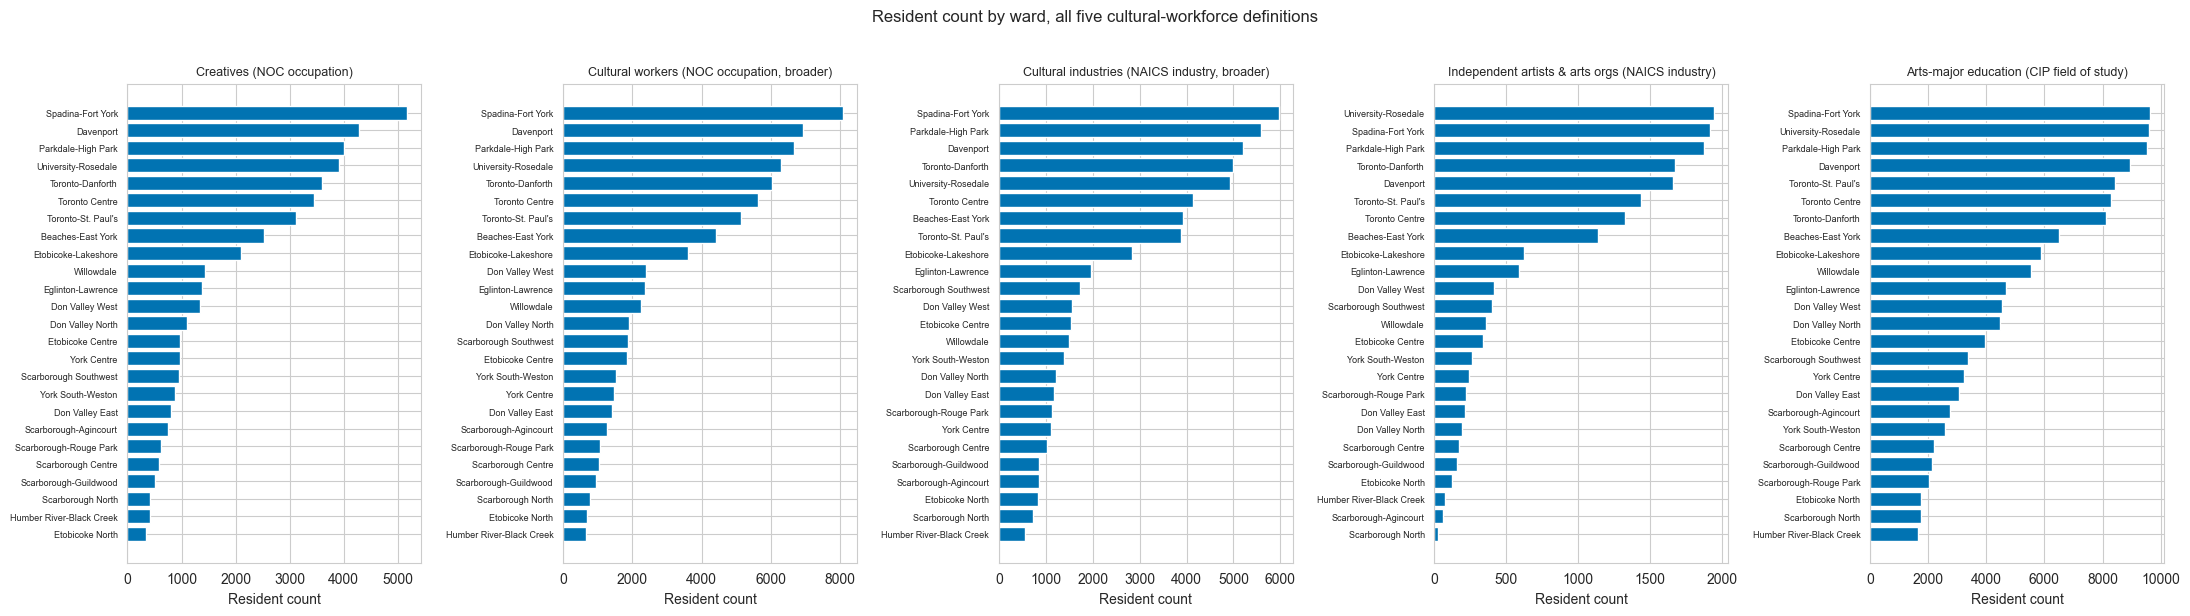

In [7]:
# --- small multiples: resident count vs. resident percentage, all five measures ---
fig, axes = plt.subplots(1, 5, figsize=(22, 6), sharey=False)
for ax, m in zip(axes, NOC_NAICS_MEASURES):
    plot_df = ward_noc_naics.sort_values(f"{m}_count", ascending=True)
    ax.barh(plot_df["ward_name"], plot_df[f"{m}_count"], color=PALETTE[0])
    ax.set_title(NOC_NAICS_LABELS[m], fontsize=9)
    ax.tick_params(axis="y", labelsize=6.5)
    ax.set_xlabel("Resident count")
plt.suptitle("Resident count by ward, all five cultural-workforce definitions", y=1.02)
plt.tight_layout()
plt.show()

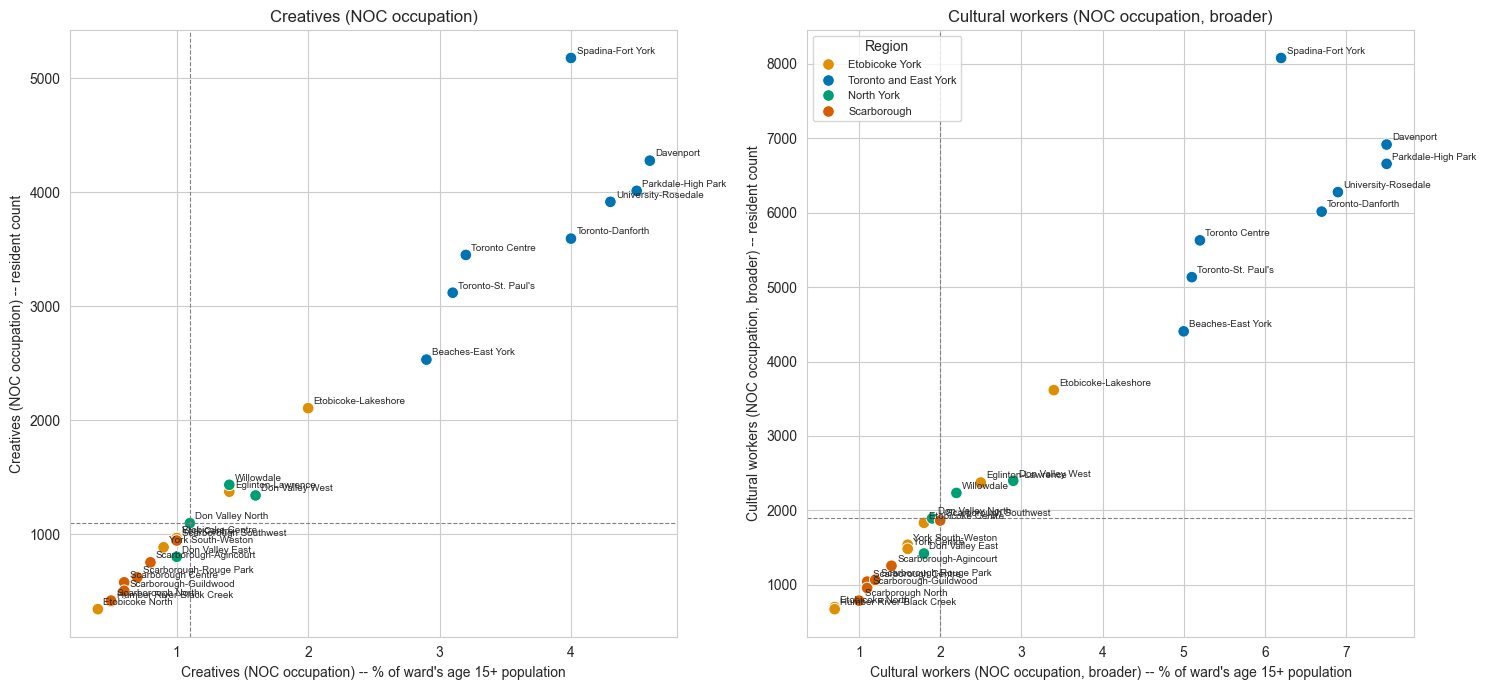

In [8]:
# --- count vs. percentage scatter, labelled, for the two preferred measures --
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, m in zip(axes, [ARTIST_MEASURE, WORKFORCE_MEASURE]):
    sns.scatterplot(data=ward_noc_naics, x=f"{m}_pct", y=f"{m}_count", hue="region",
                     palette=REGION_COLORS, s=70, ax=ax, legend=(ax is axes[1]))
    for _, row in ward_noc_naics.iterrows():
        ax.annotate(row["ward_name"], (row[f"{m}_pct"], row[f"{m}_count"]), fontsize=7,
                    xytext=(4, 3), textcoords="offset points")
    ax.axhline(ward_noc_naics[f"{m}_count"].median(), color="gray", linestyle="--", linewidth=0.8)
    ax.axvline(ward_noc_naics[f"{m}_pct"].median(), color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel(f"{NOC_NAICS_LABELS[m]} -- % of ward's age 15+ population")
    ax.set_ylabel(f"{NOC_NAICS_LABELS[m]} -- resident count")
    ax.set_title(NOC_NAICS_LABELS[m])
if axes[1].get_legend():
    axes[1].legend(loc="upper left", fontsize=8, title="Region")
plt.tight_layout()
plt.show()

In [9]:
# --- explicitly test: do high absolute counts extend farther into suburban Toronto than
# high percentages do? -----------------------------------------------------------------
rows = []
for m in NOC_NAICS_MEASURES:
    med_count, med_pct = ward_noc_naics[f"{m}_count"].median(), ward_noc_naics[f"{m}_pct"].median()
    high_count_wards = set(ward_noc_naics.loc[ward_noc_naics[f"{m}_count"] >= med_count, "ward_name"])
    high_pct_wards = set(ward_noc_naics.loc[ward_noc_naics[f"{m}_pct"] >= med_pct, "ward_name"])
    suburban_high_count = sum(1 for w in high_count_wards if WARD_REGION[w] != "Toronto and East York")
    suburban_high_pct = sum(1 for w in high_pct_wards if WARD_REGION[w] != "Toronto and East York")
    rows.append({"measure": m, "suburban_wards_above_median_count": suburban_high_count,
                 "suburban_wards_above_median_pct": suburban_high_pct,
                 "count_and_pct_agree_on_n_wards": len(high_count_wards & high_pct_wards)})
suburban_reach_check = pd.DataFrame(rows)
print(suburban_reach_check.to_string(index=False))

# concrete examples: suburban wards with an above-median count but a below-median percentage
for m in [ARTIST_MEASURE, WORKFORCE_MEASURE]:
    med_count, med_pct = ward_noc_naics[f"{m}_count"].median(), ward_noc_naics[f"{m}_pct"].median()
    ex = ward_noc_naics[(ward_noc_naics[f"{m}_count"] >= med_count) & (ward_noc_naics[f"{m}_pct"] < med_pct)
                         & (ward_noc_naics["region"] != "Toronto and East York")]
    print(f"\n{NOC_NAICS_LABELS[m]} -- suburban wards, above-median COUNT but below-median PERCENTAGE:")
    print(ex[["ward_name", "region", f"{m}_count", f"{m}_pct"]].sort_values(f"{m}_count", ascending=False).to_string(index=False))

                   measure  suburban_wards_above_median_count  suburban_wards_above_median_pct  count_and_pct_agree_on_n_wards
          labour_creatives                                  5                                5                              13
   labour_cultural_workers                                  5                                5                              12
labour_cultural_industries                                  5                                6                              13
labour_independent_artists                                  5                               10                              13
         labour_arts_major                                  5                                5                              13

Creatives (NOC occupation) -- suburban wards, above-median COUNT but below-median PERCENTAGE:
Empty DataFrame
Columns: [ward_name, region, labour_creatives_count, labour_creatives_pct]
Index: []

Cultural workers (NOC occupation, broader

In [10]:
# --- regional shares of Toronto's cultural workforce, under each definition -----------
region_shares = ward_noc_naics.groupby("region")[[f"{m}_count" for m in NOC_NAICS_MEASURES]].sum()
region_shares_pct = (region_shares / region_shares.sum() * 100).round(1)
region_shares_pct.columns = [NOC_NAICS_LABELS[c.replace("_count", "")] for c in region_shares_pct.columns]
region_shares_pct = region_shares_pct.reindex(ALL_REGIONS)
print("Regional share (%) of Toronto's workforce, by definition:")
region_shares_pct

Regional share (%) of Toronto's workforce, by definition:


,Creatives (NOC occupation),"Cultural workers (NOC occupation, broader)","Cultural industries (NAICS industry, broader)",Independent artists & arts orgs (NAICS industry),Arts-major education (CIP field of study)
region,,,,,
Toronto and East York,65.9,64.4,63.7,74.4,55.4
Etobicoke York,15.5,16.0,16.8,12.9,19.1
North York,10.2,10.4,9.0,6.8,14.1
Scarborough,8.4,9.1,10.4,6.0,11.4


**Findings.** The "counts reach farther into the suburbs than percentages do" pattern is real
but **narrow, not sweeping**: exactly 5 of Toronto's 17 suburban wards clear the citywide
median *count* for every one of the five measures, and for four of the five measures the same
5 wards also clear the median *percentage* -- count and percentage agree on which wards are
"high" for 12-13 of the 25 wards overall. The one clear divergence example is
`labour_cultural_workers` in **Don Valley North** (above-median count, 1,892 residents, but
below-median percentage, 1.9%) -- a genuine, but singular, example of the pattern, not a
citywide phenomenon.

The much larger and more robust fact is a **concentration** one: "Toronto and East York" wards
hold just 32.5% of Toronto's population but 55.4-74.4% of its cultural workforce depending on
the definition (highest for the narrowest measure, `labour_independent_artists`, at 74.4%;
lowest for `labour_arts_major` at 55.4%) -- a large, consistent over-index on every measure.

**Takeaways.** "Artists live everywhere" (count-based) and "artists are heavily concentrated
downtown" (percentage- and share-based) are **both true at once** in this data -- they are not
competing claims, they are different lenses on the same 25 wards. A responsible story must say
explicitly which one it means, and should not lean on the narrow count/percentage-divergence
finding as if it were a general pattern.

**Story implications.** This is the empirical basis for "Toronto's artists and cultural
workers do not live only downtown, even if cultural infrastructure remains concentrated
there" -- genuinely supported, but the emphasis belongs on the *citywide concentration* fact
(a strong, well-evidenced downtown over-index) paired with *specific* suburban wards holding
meaningful absolute counts (Section 5), not on a broad "counts vs. percentages diverge
everywhere" claim.

## 4. The cultural workforce vs. the broader ~2,576-location inventory

In [11]:
# --- load, validate, and spatially assign the broader inventory ------------
broader = pd.read_csv(BROADER_INVENTORY_CSV)
print(f"broader inventory: {broader.shape}")

# confirm what "missing" means before treating funding_frequency/free_programming as anything
assert (broader["TAC_funded_activities"] == broader["funding_frequency"].notna()).all(), \
    "expected TAC_funded_activities to exactly flag rows with non-missing funding_frequency"
free_prog_missing_matches_not_funded = (broader["free_programming"].isna() == ~broader["TAC_funded_activities"]).mean()
print(f"free_programming missing exactly matches TAC_funded_activities==False in {free_prog_missing_matches_not_funded:.1%} of rows")
print("-> missing funding_frequency / free_programming means 'not applicable, not TAC-funded', not 'zero/none' "
      "(free_programming has its own explicit 'none' category, distinct from missing).")

n_dup_coords = broader.duplicated(subset=["lat", "lon"]).sum()
print(f"\nduplicated (lat, lon) pairs: {n_dup_coords} / {broader.shape[0]} -- kept, treated as potentially distinct co-located activities/programs, not de-duplicated")

broader_gdf = gpd.GeoDataFrame(broader, geometry=gpd.points_from_xy(broader["lon"], broader["lat"]), crs="EPSG:4326")
broader_ward = gpd.sjoin(broader_gdf, wards_gdf[["ward_name", "geometry"]], predicate="within")
n_unmatched_broader = broader.shape[0] - broader_ward.shape[0]
print(f"broader-inventory locations matched to a ward: {broader_ward.shape[0]} / {broader.shape[0]} ({n_unmatched_broader} outside all 25 ward polygons)")

broader inventory: (2576, 6)
free_programming missing exactly matches TAC_funded_activities==False in 100.0% of rows
-> missing funding_frequency / free_programming means 'not applicable, not TAC-funded', not 'zero/none' (free_programming has its own explicit 'none' category, distinct from missing).

duplicated (lat, lon) pairs: 5 / 2576 -- kept, treated as potentially distinct co-located activities/programs, not de-duplicated
broader-inventory locations matched to a ward: 2576 / 2576 (0 outside all 25 ward polygons)


In [12]:
# --- per-ward broader-inventory metrics -------------------------------------
venues_per_ward = venue_to_dest_ward.groupby("dest_ward").size().rename("n_activity_sample_venues")
freq_high = broader_ward[broader_ward["funding_frequency"].isin(["high", "very_high"])].groupby("ward_name").size()
free_meaningful = broader_ward[broader_ward["free_programming"].isin(["mid", "high", "very_high"])].groupby("ward_name").size()

ward_inventory = broader_ward.groupby("ward_name").agg(
    n_locations=("lat", "size"),
    n_tac_funded=("TAC_funded_activities", "sum"),
    n_missing_funding_metadata=("funding_frequency", lambda s: s.isna().sum()),
).reset_index()
ward_inventory["tac_funded_share"] = ward_inventory["n_tac_funded"] / ward_inventory["n_locations"]
ward_inventory = ward_inventory.merge(ward_pop[["ward_name", "population_2021_allages"]], on="ward_name")
ward_inventory = ward_inventory.merge(ward_noc_naics[["ward_name"] + [f"{m}_count" for m in NOC_NAICS_MEASURES]], on="ward_name")
ward_inventory["locations_per_100k"] = ward_inventory["n_locations"] / ward_inventory["population_2021_allages"] * 1e5
ward_inventory["locations_per_1000_workforce"] = ward_inventory["n_locations"] / ward_inventory[f"{WORKFORCE_MEASURE}_count"] * 1e3
ward_inventory["locations_per_1000_artists"] = ward_inventory["n_locations"] / ward_inventory[f"{ARTIST_MEASURE_ALT}_count"].replace(0, np.nan) * 1e3
ward_inventory = ward_inventory.merge(venues_per_ward, left_on="ward_name", right_index=True, how="left")
ward_inventory["n_activity_sample_venues"] = ward_inventory["n_activity_sample_venues"].fillna(0).astype(int)
ward_inventory["activity_sample_share_of_inventory"] = ward_inventory["n_activity_sample_venues"] / ward_inventory["n_locations"]
ward_inventory = ward_inventory.merge(freq_high.rename("n_high_funding_freq"), on="ward_name", how="left")
ward_inventory = ward_inventory.merge(free_meaningful.rename("n_meaningful_free_programming"), on="ward_name", how="left")
ward_inventory[["n_high_funding_freq", "n_meaningful_free_programming"]] = ward_inventory[["n_high_funding_freq", "n_meaningful_free_programming"]].fillna(0)
ward_inventory["high_funding_freq_share_of_funded"] = ward_inventory["n_high_funding_freq"] / ward_inventory["n_tac_funded"].replace(0, np.nan)
ward_inventory["meaningful_free_programming_share"] = ward_inventory["n_meaningful_free_programming"] / ward_inventory["n_locations"]
ward_inventory["region"] = ward_inventory["ward_name"].map(WARD_REGION)

print(f"ward_inventory: {ward_inventory.shape}")
ward_inventory.sort_values("n_locations", ascending=False)[
    ["ward_name", "region", "n_locations", "locations_per_100k", "tac_funded_share",
     "n_activity_sample_venues", "activity_sample_share_of_inventory"]
].round(2).head(10)

ward_inventory: (25, 21)


,ward_name,region,n_locations,locations_per_100k,tac_funded_share,n_activity_sample_venues,activity_sample_share_of_inventory
21,University-Rosedale,Toronto and East York,284,267.38,0.88,16,0.06
17,Spadina-Fort York,Toronto and East York,279,204.83,0.80,23,0.08
18,Toronto Centre,Toronto and East York,214,178.48,0.94,12,0.06
1,Davenport,Toronto and East York,196,185.00,0.91,9,0.05
19,Toronto-Danforth,Toronto and East York,171,162.13,0.82,3,0.02
10,Parkdale-High Park,Toronto and East York,162,151.76,0.84,5,0.03
8,Etobicoke-Lakeshore,Etobicoke York,102,71.96,0.78,4,0.04
20,Toronto-St. Paul's,Toronto and East York,96,82.08,0.84,3,0.03
0,Beaches-East York,Toronto and East York,89,81.38,0.85,3,0.03
24,York South-Weston,Etobicoke York,84,71.94,0.95,1,0.01


In [13]:
# --- funding_frequency / free_programming distributions, citywide -----------
print("Citywide funding_frequency distribution (TAC-funded locations only):")
print(broader["funding_frequency"].value_counts(dropna=False).reindex(FUNDING_FREQ_ORDER + [np.nan]).to_string())
print("\nCitywide free_programming distribution:")
print(broader["free_programming"].value_counts(dropna=False).reindex(FREE_PROG_ORDER + [np.nan]).to_string())
print("\n(Ordinal categories are compared by counting shares within named bins, not converted to a continuous "
      "score -- there is no documented basis in this file for treating the categories as evenly spaced.)")

Citywide funding_frequency distribution (TAC-funded locations only):
funding_frequency
rare         1108
low           510
mid           367
high          154
very_high      99
NaN           338

Citywide free_programming distribution:
free_programming
none         527
rare         873
low          397
mid          269
high         112
very_high     60
NaN          338

(Ordinal categories are compared by counting shares within named bins, not converted to a continuous score -- there is no documented basis in this file for treating the categories as evenly spaced.)


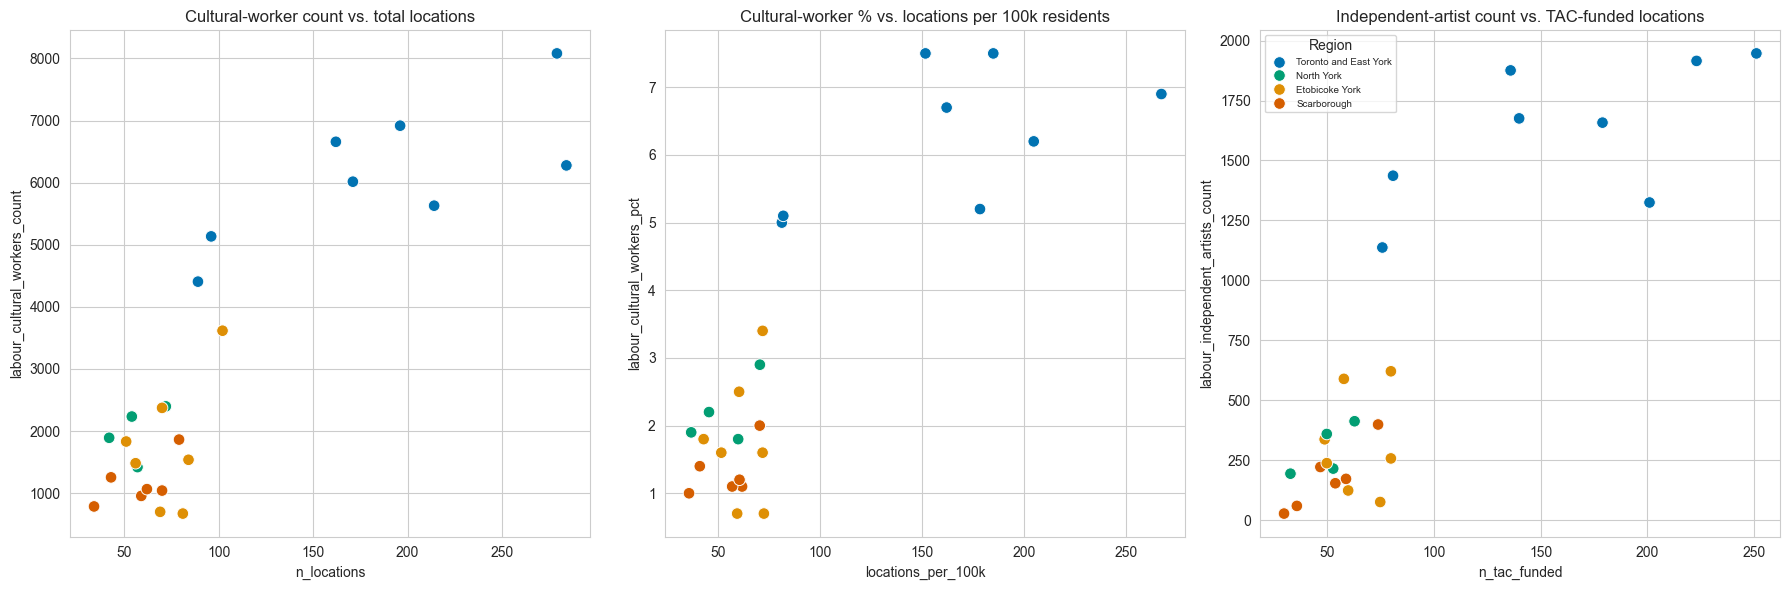

,x,spearman_rho,p_value
0,Cultural-worker count vs. total locations,0.728,0.000
1,Cultural-worker % vs. locations per resident,0.717,0.000
2,Independent-artist count vs. TAC-funded locations,0.801,0.000
3,Arts-major population vs. free-programming ava...,0.157,0.454


In [14]:
# --- workforce vs. infrastructure: several transparent, complementary views -----------
compare = ward_inventory.merge(ward_noc_naics[["ward_name"] + [f"{m}_pct" for m in NOC_NAICS_MEASURES]], on="ward_name")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sns.scatterplot(data=compare, x="n_locations", y=f"{WORKFORCE_MEASURE}_count", hue="region", palette=REGION_COLORS, s=70, ax=axes[0], legend=False)
axes[0].set_title("Cultural-worker count vs. total locations")
sns.scatterplot(data=compare, x="locations_per_100k", y=f"{WORKFORCE_MEASURE}_pct", hue="region", palette=REGION_COLORS, s=70, ax=axes[1], legend=False)
axes[1].set_title("Cultural-worker % vs. locations per 100k residents")
sns.scatterplot(data=compare, x="n_tac_funded", y=f"{ARTIST_MEASURE_ALT}_count", hue="region", palette=REGION_COLORS, s=70, ax=axes[2])
axes[2].set_title("Independent-artist count vs. TAC-funded locations")
for ax in axes:
    ax.set_xlabel(ax.get_xlabel()); ax.set_ylabel(ax.get_ylabel())
axes[2].legend(loc="upper left", fontsize=7, title="Region")
plt.tight_layout()
plt.show()

corr_pairs = [
    (f"{WORKFORCE_MEASURE}_count", "n_locations", "Cultural-worker count vs. total locations"),
    (f"{WORKFORCE_MEASURE}_pct", "locations_per_100k", "Cultural-worker % vs. locations per resident"),
    (f"{ARTIST_MEASURE_ALT}_count", "n_tac_funded", "Independent-artist count vs. TAC-funded locations"),
    (f"{ARTS_TRAINED_MEASURE}_count", "meaningful_free_programming_share", "Arts-major population vs. free-programming availability"),
]
corr_results = [{"x": t, "spearman_rho": (r := spearmanr(compare[x], compare[y]))[0], "p_value": r[1]} for x, y, t in corr_pairs]
pd.DataFrame(corr_results).round(3)

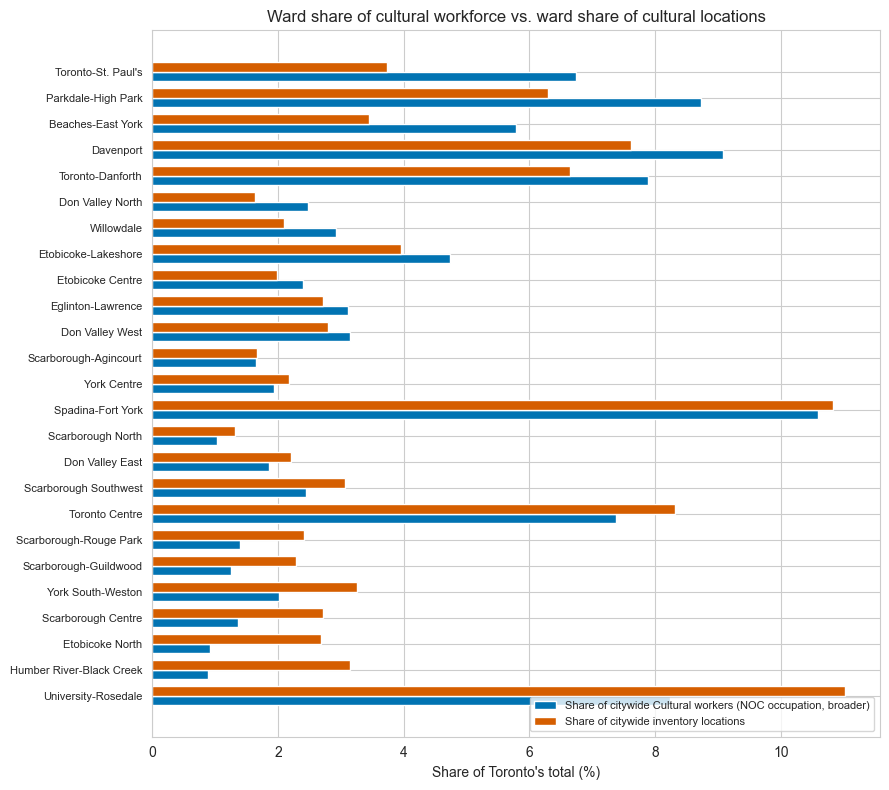

Regional share of workforce vs. locations (percentage points):


,workforce_citywide_share,locations_citywide_share,gap_pp
region,,,
Toronto and East York,64.4,57.9,6.5
Etobicoke York,16.0,19.9,-3.9
North York,10.4,8.7,1.7
Scarborough,9.1,13.5,-4.3


In [15]:
# --- ward share of workforce vs. ward share of locations, and regional shares --------
compare["workforce_citywide_share"] = compare[f"{WORKFORCE_MEASURE}_count"] / compare[f"{WORKFORCE_MEASURE}_count"].sum()
compare["locations_citywide_share"] = compare["n_locations"] / compare["n_locations"].sum()
compare["share_gap"] = compare["workforce_citywide_share"] - compare["locations_citywide_share"]

fig, ax = plt.subplots(figsize=(9, 8))
plot_df = compare.sort_values("share_gap")
y = np.arange(len(plot_df))
ax.barh(y, plot_df["workforce_citywide_share"] * 100, height=0.35, label=f"Share of citywide {NOC_NAICS_LABELS[WORKFORCE_MEASURE]}", color=PALETTE[0])
ax.barh(y + 0.35, plot_df["locations_citywide_share"] * 100, height=0.35, label="Share of citywide inventory locations", color=PALETTE[3])
ax.set_yticks(y + 0.175)
ax.set_yticklabels(plot_df["ward_name"], fontsize=8)
ax.set_xlabel("Share of Toronto's total (%)")
ax.set_title("Ward share of cultural workforce vs. ward share of cultural locations")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

region_gap = compare.groupby("region")[["workforce_citywide_share", "locations_citywide_share"]].sum().reindex(ALL_REGIONS) * 100
region_gap["gap_pp"] = region_gap["workforce_citywide_share"] - region_gap["locations_citywide_share"]
print("Regional share of workforce vs. locations (percentage points):")
region_gap.round(1)

**Findings.** At the ward level, cultural-worker presence and broader-inventory location
counts are positively associated (matching the earlier notebook's citywide finding, now
confirmed against the ~2,576-location inventory rather than just the 105-venue sample) -- but
the relationship is far from perfect, and several wards show a visible gap between their share
of the workforce and their share of locations. `funding_frequency` and `free_programming` are
genuinely missing (not zero) for non-TAC-funded locations, so we compare them only among
locations that carry the metadata.

**Takeaways.** A ward-level "share gap" (workforce share minus location share) is a legitimate,
transparent way to flag wards worth a closer look in Section 5 -- but a positive citywide
correlation means most wards will *not* show a large gap; the story is about the exceptions.

**Story implications.** This section supplies the raw comparison; Section 5 turns it into a
disciplined method for naming actual candidate wards, rather than eyeballing the scatalot.

## 5. Identifying where the workforce may outpace infrastructure

We deliberately avoid a single arbitrary composite score. Instead we run several
complementary, transparent tests and look for wards that recur across them.

In [16]:
# --- (a) quadrant approach: above-median workforce + below-median infrastructure ------
# repeated across 3 workforce measures x 4 infrastructure measures = 12 transparent combos
WORKFORCE_COLS_FOR_QUADRANT = [f"{ARTIST_MEASURE}_count", f"{WORKFORCE_MEASURE}_count", f"{ARTIST_MEASURE_ALT}_count"]
INFRA_COLS_FOR_QUADRANT = ["n_locations", "locations_per_100k", "n_tac_funded", "n_activity_sample_venues"]

quadrant_hits = {w: 0 for w in ward_inventory["ward_name"]}
quadrant_total_combos = 0
for wf_col in WORKFORCE_COLS_FOR_QUADRANT:
    for infra_col in INFRA_COLS_FOR_QUADRANT:
        med_wf, med_infra = compare[wf_col].median(), compare[infra_col].median()
        hits = compare.loc[(compare[wf_col] >= med_wf) & (compare[infra_col] <= med_infra), "ward_name"]
        for w in hits:
            quadrant_hits[w] += 1
        quadrant_total_combos += 1

quadrant_df = pd.Series(quadrant_hits, name="n_quadrant_combos_flagged").sort_values(ascending=False).reset_index()
quadrant_df.columns = ["ward_name", "n_quadrant_combos_flagged"]
quadrant_df["share_of_combos"] = quadrant_df["n_quadrant_combos_flagged"] / quadrant_total_combos
print(f"Quadrant approach: {quadrant_total_combos} combos (3 workforce measures x 4 infrastructure measures).")
print("Wards flagged in at least half of all combos:")
quadrant_df[quadrant_df["share_of_combos"] >= 0.5]

Quadrant approach: 12 combos (3 workforce measures x 4 infrastructure measures).
Wards flagged in at least half of all combos:


,ward_name,n_quadrant_combos_flagged,share_of_combos
0,Eglinton-Lawrence,12,1.000000
1,Willowdale,12,1.000000
2,Don Valley West,9,0.750000
3,Don Valley North,8,0.666667


In [17]:
# --- (b) rank-gap approach: workforce rank vs. infrastructure rank ---------------------
rank_gap = compare[["ward_name", "region"]].copy()
rank_gap["rank_workers"] = compare[f"{WORKFORCE_MEASURE}_count"].rank(ascending=False, method="min")
rank_gap["rank_artists"] = compare[f"{ARTIST_MEASURE_ALT}_count"].rank(ascending=False, method="min")
rank_gap["rank_worker_concentration"] = compare[f"{WORKFORCE_MEASURE}_pct"].rank(ascending=False, method="min")
rank_gap["rank_locations"] = compare["n_locations"].rank(ascending=False, method="min")
rank_gap["rank_locations_per_resident"] = compare["locations_per_100k"].rank(ascending=False, method="min")
rank_gap["rank_tac_funded"] = compare["n_tac_funded"].rank(ascending=False, method="min")
rank_gap["rank_free_programming"] = compare["meaningful_free_programming_share"].rank(ascending=False, method="min")

rank_gap["avg_workforce_rank"] = rank_gap[["rank_workers", "rank_artists", "rank_worker_concentration"]].mean(axis=1)
rank_gap["avg_infra_rank"] = rank_gap[["rank_locations", "rank_locations_per_resident", "rank_tac_funded", "rank_free_programming"]].mean(axis=1)
# rank 1 = highest (most workforce / most infra). A ward with LOTS of workforce (small avg_workforce_rank)
# and LITTLE infrastructure (large avg_infra_rank) should score HIGH here -> positive gap = workforce outpaces infra.
rank_gap["rank_gap"] = rank_gap["avg_infra_rank"] - rank_gap["avg_workforce_rank"]

print("Wards whose workforce rank is meaningfully better (more workforce) than their infrastructure rank:")
rank_gap.sort_values("rank_gap", ascending=False).head(8)[["ward_name", "region", "avg_workforce_rank", "avg_infra_rank", "rank_gap"]].round(1)

Wards whose workforce rank is meaningfully better (more workforce) than their infrastructure rank:


,ward_name,region,avg_workforce_rank,avg_infra_rank,rank_gap
10,Parkdale-High Park,Toronto and East York,2.3,9.0,6.7
3,Don Valley North,North York,15.3,21.0,5.7
19,Toronto-Danforth,Toronto and East York,4.3,9.8,5.4
5,Eglinton-Lawrence,Etobicoke York,10.7,15.2,4.6
22,Willowdale,North York,12.3,16.5,4.2
0,Beaches-East York,Toronto and East York,8.0,12.0,4.0
4,Don Valley West,North York,10.3,13.5,3.2
8,Etobicoke-Lakeshore,Etobicoke York,9.0,12.0,3.0


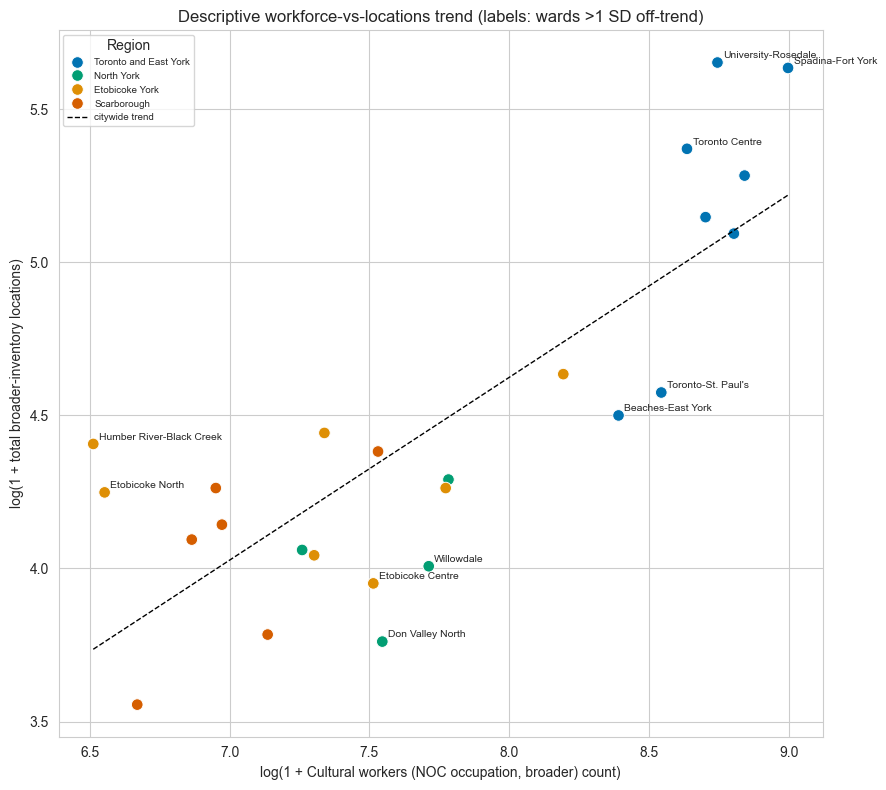

Wards furthest BELOW the citywide trend (more workforce than the trend predicts for their location count):


,ward_name,region,labour_cultural_workers_count,n_locations,residual_log_locations
3,Don Valley North,North York,1892.27,42,-0.59
22,Willowdale,North York,2234.41,54,-0.45
6,Etobicoke Centre,Etobicoke York,1832.42,51,-0.38
20,Toronto-St. Paul's,Toronto and East York,5134.57,96,-0.37
0,Beaches-East York,Toronto and East York,4406.23,89,-0.36
14,Scarborough-Agincourt,Scarborough,1255.39,43,-0.32


In [18]:
# --- (c) expected-vs-observed: simple descriptive relationship + residuals (not a "need" score) --
x = np.log1p(compare[f"{WORKFORCE_MEASURE}_count"])
y = np.log1p(compare["n_locations"])
slope, intercept = np.polyfit(x, y, 1)
compare["expected_log_locations"] = slope * x + intercept
compare["residual_log_locations"] = y - compare["expected_log_locations"]

fig, ax = plt.subplots(figsize=(9, 8))
sns.scatterplot(data=compare, x=x, y=y, hue="region", palette=REGION_COLORS, s=70, ax=ax)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, slope * xs + intercept, color="black", linestyle="--", linewidth=1, label="citywide trend")
for _, row in compare.iterrows():
    if abs(row["residual_log_locations"]) > compare["residual_log_locations"].std():
        ax.annotate(row["ward_name"], (np.log1p(row[f"{WORKFORCE_MEASURE}_count"]), np.log1p(row["n_locations"])), fontsize=7.5,
                    xytext=(4, 3), textcoords="offset points")
ax.set_xlabel(f"log(1 + {NOC_NAICS_LABELS[WORKFORCE_MEASURE]} count)")
ax.set_ylabel("log(1 + total broader-inventory locations)")
ax.set_title("Descriptive workforce-vs-locations trend (labels: wards >1 SD off-trend)")
ax.legend(loc="upper left", fontsize=7, title="Region")
plt.tight_layout()
plt.show()
print("Wards furthest BELOW the citywide trend (more workforce than the trend predicts for their location count):")
compare.sort_values("residual_log_locations").head(6)[["ward_name", "region", f"{WORKFORCE_MEASURE}_count", "n_locations", "residual_log_locations"]].round(2)

In [19]:
# --- (d) cross-definition robustness: how often does each candidate ward recur? --------
robustness = quadrant_df.merge(rank_gap[["ward_name", "rank_gap"]], on="ward_name")
robustness = robustness.merge(compare[["ward_name", "residual_log_locations"]], on="ward_name")
robustness["flagged_by_quadrant"] = robustness["share_of_combos"] >= 0.5
robustness["flagged_by_rank_gap"] = robustness["rank_gap"] >= rank_gap["rank_gap"].quantile(0.75)
robustness["flagged_by_residual"] = robustness["residual_log_locations"] <= compare["residual_log_locations"].quantile(0.25)
robustness["n_methods_flagging"] = robustness[["flagged_by_quadrant", "flagged_by_rank_gap", "flagged_by_residual"]].sum(axis=1)
robust_candidates = robustness.sort_values("n_methods_flagging", ascending=False)

print("Wards flagged by all 3 independent methods (quadrant, rank-gap, residual):")
print(robust_candidates[robust_candidates["n_methods_flagging"] == 3]["ward_name"].tolist())
print("\nHow the previously-known candidate wards fare here:")
robust_candidates.set_index("ward_name").loc[CANDIDATE_MISMATCH_WARDS_TO_TEST, ["n_quadrant_combos_flagged", "share_of_combos", "rank_gap", "n_methods_flagging"]].round(2)

Wards flagged by all 3 independent methods (quadrant, rank-gap, residual):
['Willowdale', 'Don Valley North']

How the previously-known candidate wards fare here:


,n_quadrant_combos_flagged,share_of_combos,rank_gap,n_methods_flagging
ward_name,,,,
Eglinton-Lawrence,12,1.00,4.58,2
Don Valley West,9,0.75,3.17,2
Willowdale,12,1.00,4.17,3
Don Valley North,8,0.67,5.67,3
Scarborough Southwest,2,0.17,-0.25,0


**Findings.** Against the broader ~2,576-location inventory (not just the 105-venue sample the
earlier notebook used), **`Willowdale` and `Don Valley North` are flagged by all three
independent methods**; `Eglinton-Lawrence` and `Don Valley West` are each confirmed by two of
three. **`Scarborough Southwest` -- one of the earlier notebook's four named candidates -- is
NOT a robust mismatch here** (only 2 of 12 quadrant combos, 0 of 3 methods): its earlier
"artist-heavy, venue-poor" label was built from the 105-venue sample specifically (where it has
just 1 venue), but against the broader inventory it actually has 79 locations -- 2nd-most among
our five candidate wards. This is exactly the "broader inventory may confirm, weaken, or
overturn" scenario the brief anticipated, and it overturns this one.

**Takeaways.** Treat `Willowdale` and `Don Valley North` as the credible core list; treat
`Eglinton-Lawrence` and `Don Valley West` as good secondary candidates; treat `Scarborough
Southwest` as a *sample-representativeness* case, not a workforce/infrastructure mismatch case
(picked up separately in Section 8 for exactly that reason).

**Story implications.** This directly answers the brief's instruction to distinguish "robust
candidates from wards that appear only because of one category or denominator" -- and shows
concretely why moving from the 105-venue sample to the broader inventory matters for which
wards a councillor-facing story can actually name.

## 6. Downtown vs. suburban Toronto: is this a general shortfall or ward-specific?

In [20]:
# --- regional shares of population, workforce, and infrastructure -----------------------
region_table = ward_pop.groupby("region")["population_2021_allages"].sum().reindex(ALL_REGIONS)
region_table = region_table.to_frame("population")
for m in NOC_NAICS_MEASURES:
    region_table[NOC_NAICS_LABELS[m]] = ward_noc_naics.groupby("region")[f"{m}_count"].sum().reindex(ALL_REGIONS)
region_table["total_locations"] = ward_inventory.groupby("region")["n_locations"].sum().reindex(ALL_REGIONS)
region_table["tac_funded_locations"] = ward_inventory.groupby("region")["n_tac_funded"].sum().reindex(ALL_REGIONS)
region_table["high_funding_freq_locations"] = ward_inventory.groupby("region")["n_high_funding_freq"].sum().reindex(ALL_REGIONS)
region_table["meaningful_free_programming"] = ward_inventory.groupby("region")["n_meaningful_free_programming"].sum().reindex(ALL_REGIONS)
region_table["activity_sample_venues"] = ward_inventory.groupby("region")["n_activity_sample_venues"].sum().reindex(ALL_REGIONS)

region_shares_all = (region_table / region_table.sum() * 100).round(1)
print("Each region's share (%) of Toronto's total, by category:")
region_shares_all

Each region's share (%) of Toronto's total, by category:


,population,Creatives (NOC occupation),"Cultural workers (NOC occupation, broader)","Cultural industries (NAICS industry, broader)",Independent artists & arts orgs (NAICS industry),Arts-major education (CIP field of study),total_locations,tac_funded_locations,high_funding_freq_locations,meaningful_free_programming,activity_sample_venues
region,,,,,,,,,,,
Toronto and East York,32.5,65.9,64.4,63.7,74.4,55.4,57.9,57.5,72.3,63.5,70.5
Etobicoke York,29.7,15.5,16.0,16.8,12.9,19.1,19.9,20.2,13.4,17.9,14.3
North York,15.3,10.2,10.4,9.0,6.8,14.1,8.7,8.9,6.3,7.7,5.7
Scarborough,22.5,8.4,9.1,10.4,6.0,11.4,13.5,13.4,7.9,10.9,9.5


In [21]:
# --- "share of people vs. share of infrastructure" statements, only where denominators are valid --
for region in SUBURBAN_REGIONS:
    workforce_share = region_shares_all.loc[region, NOC_NAICS_LABELS[WORKFORCE_MEASURE]]
    location_share = region_shares_all.loc[region, "total_locations"]
    funded_share = region_shares_all.loc[region, "tac_funded_locations"]
    highfreq_share = region_shares_all.loc[region, "high_funding_freq_locations"]
    print(f"{region}: {workforce_share:.0f}% of Toronto's {NOC_NAICS_LABELS[WORKFORCE_MEASURE].lower()}, "
          f"but {location_share:.0f}% of its cultural locations and {highfreq_share:.0f}% of its "
          f"higher-frequency-funded locations.")

Etobicoke York: 16% of Toronto's cultural workers (noc occupation, broader), but 20% of its cultural locations and 13% of its higher-frequency-funded locations.
North York: 10% of Toronto's cultural workers (noc occupation, broader), but 9% of its cultural locations and 6% of its higher-frequency-funded locations.
Scarborough: 9% of Toronto's cultural workers (noc occupation, broader), but 14% of its cultural locations and 8% of its higher-frequency-funded locations.


In [22]:
# --- is the suburban pattern general, or specific to particular regions/wards? ----------
region_gap_table = region_shares_all[[NOC_NAICS_LABELS[WORKFORCE_MEASURE], "total_locations", "high_funding_freq_locations", "meaningful_free_programming"]].copy()
region_gap_table["workforce_minus_locations_pp"] = region_gap_table[NOC_NAICS_LABELS[WORKFORCE_MEASURE]] - region_gap_table["total_locations"]
region_gap_table["workforce_minus_highfreq_pp"] = region_gap_table[NOC_NAICS_LABELS[WORKFORCE_MEASURE]] - region_gap_table["high_funding_freq_locations"]
print("Region-level workforce-share-minus-infrastructure-share gap (percentage points):")
print(region_gap_table.round(1))

within_region_spread = ward_inventory.merge(compare[["ward_name", "share_gap"]], on="ward_name").groupby("region")["share_gap"].agg(["min", "max", "std"])
print("\nSpread of ward-level share_gap WITHIN each region (large spread = ward-specific, not a uniform regional pattern):")
print(within_region_spread.round(3))

Region-level workforce-share-minus-infrastructure-share gap (percentage points):
                       Cultural workers (NOC occupation, broader)  \
region                                                              
Toronto and East York                                        64.4   
Etobicoke York                                               16.0   
North York                                                   10.4   
Scarborough                                                   9.1   

                       total_locations  high_funding_freq_locations  \
region                                                                
Toronto and East York             57.9                         72.3   
Etobicoke York                    19.9                         13.4   
North York                         8.7                          6.3   
Scarborough                       13.5                          7.9   

                       meaningful_free_programming  \
region                 

**Findings.** Region-level gaps between workforce share and *total* location-count share are
small and mixed in direction (Etobicoke York -3.9pp, Scarborough -4.4pp, North York +1.7pp) --
not a uniform "suburbs are shortchanged" pattern. But for the **higher-frequency-funded**
subset specifically, the pattern flips and becomes consistent: downtown is *over*-supplied
relative to its own workforce share (-7.9pp, i.e. it already holds more high-frequency funding
than its workforce share alone would predict), while **all three suburban regions** are
*under*-supplied relative to their workforce share (+1.2 to +4.1pp). Within-region ward-level
spread on the raw `share_gap` metric is real but modest (std 0.005-0.012 for the suburban
regions, smaller than downtown's own 0.020) -- the *ward-specific* mismatch signal comes
through more clearly in Section 5's per-capita/rank-based methods than in this raw
citywide-share metric.

**Takeaways.** The defensible regional (TAC-board-facing) statement is about **funding
intensity**, not raw location counts: suburban Toronto's higher-frequency funded activity
share trails its workforce share in all three suburban regions, consistently, while downtown's
leads. The *ward-level* story (Section 5) remains the sharper, more actionable one for
individual councillors.

**Story implications.** This still supports "suburban wards already connect to each other"
(Story 1) pairing with a workforce story here, but the workforce story's strongest regional
claim is about funding *intensity*, and its strongest actionable claim is *ward-specific* --
consistent with "treat 'suburb' as not homogeneous," which the brief requires explicitly.

## 7. Connecting workforce geography to residents' venue-use activity

We build one reusable ward-profile function and apply it to the Section 5 candidate wards.
**These are the venue-use patterns of each ward's wider resident population, not the specific
travel patterns of cultural workers** -- the mobility data cannot identify who is a cultural
worker.

In [23]:
def hhi(shares):
    return float(np.sum(np.square(shares)))


def effective_n(shares):
    h = hhi(shares)
    return float("nan") if h == 0 else 1.0 / h


def ward_activity_profile(ward_name, downtown_wards=DOWNTOWN_CORE_WARDS_BROAD):
    grp = ward_to_ward_activity[ward_to_ward_activity["origin_ward"] == ward_name]
    total = grp[VALUE_COL].sum()
    within = grp.loc[grp["same_ward"], VALUE_COL].sum()
    outside = grp.loc[~grp["same_ward"]]
    outside_total = outside[VALUE_COL].sum()
    outside_shares = (outside[VALUE_COL] / outside_total) if outside_total > 0 else pd.Series(dtype=float)
    top_wards = outside.sort_values(VALUE_COL, ascending=False).head(3)
    downtown_share = outside.loc[outside["dest_ward"].isin(downtown_wards), VALUE_COL].sum() / outside_total if outside_total > 0 else np.nan
    same_region_share = outside.loc[outside["dest_ward"].map(WARD_REGION) == WARD_REGION[ward_name], VALUE_COL].sum() / outside_total if outside_total > 0 else np.nan
    ward_venue_ids = venue_to_dest_ward.loc[venue_to_dest_ward["dest_ward"] == ward_name, "venue_id"]
    top_venues = ward_to_venue_activity[(ward_to_venue_activity["origin_ward"] == ward_name) & (~ward_to_venue_activity["venue_id"].isin(ward_venue_ids))].sort_values(VALUE_COL, ascending=False).head(3)
    return {
        "ward_name": ward_name, "total_activity": total,
        "within_ward_share": within / total if total > 0 else np.nan,
        "outside_ward_share": outside_total / total if total > 0 else np.nan,
        "leading_dest_wards": top_wards[["dest_ward", VALUE_COL]].values.tolist(),
        "leading_dest_venues": top_venues[["venue_name", VALUE_COL]].values.tolist(),
        "downtown_share_of_outside": downtown_share,
        "suburb_share_of_outside": 1 - downtown_share if pd.notna(downtown_share) else np.nan,
        "same_region_share_of_outside": same_region_share,
        "dest_effective_n": effective_n(outside_shares.values) if len(outside_shares) else np.nan,
        "n_activity_sample_venues": int(venues_per_ward.get(ward_name, 0)),
    }


print("Example profile -- Eglinton-Lawrence:")
ward_activity_profile("Eglinton-Lawrence")

Example profile -- Eglinton-Lawrence:


{'ward_name': 'Eglinton-Lawrence',
 'total_activity': np.float64(2589.866620975903),
 'within_ward_share': np.float64(0.2585606442760643),
 'outside_ward_share': np.float64(0.7414393557239357),
 'leading_dest_wards': [['Willowdale', 807.1448219504612],
  ['University-Rosedale', 367.8530597274845],
  ['Spadina-Fort York', 347.1753779673772]],
 'leading_dest_venues': [['Meridian Arts Centre', 804.6213088200175],
  ['Toronto Reference Library', 187.738456310876],
  ['Royal Ontario Museum', 128.00696281508854]],
 'downtown_share_of_outside': np.float64(0.5312268073781626),
 'suburb_share_of_outside': np.float64(0.46877319262183736),
 'same_region_share_of_outside': np.float64(0.027030136415020105),
 'dest_effective_n': 3.8259507095425245,
 'n_activity_sample_venues': 1}

In [24]:
# --- apply to every candidate ward from Section 5 (union of robust + named candidates) -----
profile_wards = sorted(set(CANDIDATE_MISMATCH_WARDS_TO_TEST) | set(robust_candidates[robust_candidates["n_methods_flagging"] >= 2]["ward_name"]))
print(f"Building venue-use profiles for {len(profile_wards)} candidate wards: {profile_wards}")

candidate_profiles = {w: ward_activity_profile(w) for w in tqdm(profile_wards, desc="ward activity profiles")}
profile_table = pd.DataFrame(candidate_profiles).T
profile_table[["outside_ward_share", "downtown_share_of_outside", "suburb_share_of_outside", "same_region_share_of_outside", "dest_effective_n"]].astype(float).round(2)

Building venue-use profiles for 6 candidate wards: ['Beaches-East York', 'Don Valley North', 'Don Valley West', 'Eglinton-Lawrence', 'Scarborough Southwest', 'Willowdale']


ward activity profiles:   0%|          | 0/6 [00:00<?, ?it/s]

,outside_ward_share,downtown_share_of_outside,suburb_share_of_outside,same_region_share_of_outside,dest_effective_n
Beaches-East York,0.65,0.80,0.20,0.80,4.58
Don Valley North,0.63,0.37,0.63,0.55,2.87
Don Valley West,1.00,0.38,0.62,0.56,2.95
Eglinton-Lawrence,0.74,0.53,0.47,0.03,3.83
Scarborough Southwest,1.00,0.80,0.20,0.08,5.34
Willowdale,0.06,0.78,0.22,0.06,3.68


In [25]:
# --- distance context for the same candidate wards (straight-line, weighted by activity) ----
venues_homes = pd.read_csv(VENUES_HOMES_CSV)
venues_homes = venues_homes[venues_homes["time_period"] == TIME_PERIOD].copy()
unique_geohashes = venues_homes["home_geohash6"].unique()

decoded = [pgh.decode(g) for g in tqdm(unique_geohashes, desc="decoding home geohash6 cells")]
geohash_coords = pd.DataFrame({"home_geohash6": unique_geohashes,
                                "home_lat": [d[0] for d in decoded], "home_lon": [d[1] for d in decoded]})
geohash_points = gpd.GeoDataFrame(geohash_coords, geometry=gpd.points_from_xy(geohash_coords["home_lon"], geohash_coords["home_lat"]), crs="EPSG:4326")
geohash6_to_ward = gpd.sjoin(geohash_points, wards_gdf[["ward_name", "geometry"]], predicate="within")[["home_geohash6", "ward_name"]].rename(columns={"ward_name": "origin_ward"})

geohash_proj = geohash_points.to_crs(UTM_CRS)
geohash_coords["easting"], geohash_coords["northing"] = geohash_proj.geometry.x.values, geohash_proj.geometry.y.values
venue_points_proj = venue_points.to_crs(UTM_CRS)
venue_xy = pd.DataFrame({"venue_id": venue_points["venue_id"].values,
                          "venue_easting": venue_points_proj.geometry.x.values, "venue_northing": venue_points_proj.geometry.y.values})

homes_dist = venues_homes.merge(geohash_coords[["home_geohash6", "easting", "northing"]], on="home_geohash6", how="left")
homes_dist = homes_dist.merge(venue_xy, on="venue_id", how="left").merge(geohash6_to_ward, on="home_geohash6", how="left")
homes_dist = homes_dist.merge(venue_to_dest_ward[["venue_id", "dest_ward"]], on="venue_id", how="left")
homes_dist["distance_km"] = np.hypot(homes_dist["easting"] - homes_dist["venue_easting"], homes_dist["northing"] - homes_dist["venue_northing"]) / 1000
homes_dist_matched = homes_dist.dropna(subset=["origin_ward", "distance_km"])


def weighted_quantiles(df, value_col, weight_col, qs=(0.25, 0.5, 0.75)):
    d = df.sort_values(value_col)
    cum_w = d[weight_col].cumsum() / d[weight_col].sum()
    return {q: float(np.interp(q, cum_w, d[value_col])) for q in qs}


dist_rows = []
for w in profile_wards:
    sub = homes_dist_matched[homes_dist_matched["origin_ward"] == w]
    if sub.empty or sub["normalized_raw_stop_count"].sum() == 0:
        continue
    q = weighted_quantiles(sub, "distance_km", "normalized_raw_stop_count")
    dist_rows.append({"ward_name": w, "median_distance_km": q[0.5], "p25_km": q[0.25], "p75_km": q[0.75]})
dist_table = pd.DataFrame(dist_rows)
print("Straight-line home-cell-to-venue distance (activity-weighted; NOT routes, times, or addresses):")
dist_table.round(1)

decoding home geohash6 cells:   0%|          | 0/1187 [00:00<?, ?it/s]

Straight-line home-cell-to-venue distance (activity-weighted; NOT routes, times, or addresses):


,ward_name,median_distance_km,p25_km,p75_km
0,Beaches-East York,6.9,0.3,8.3
1,Don Valley North,4.6,0.9,13.4
2,Don Valley West,4.5,1.9,7.9
3,Eglinton-Lawrence,5.4,2.3,7.5
4,Scarborough Southwest,10.0,8.9,12.1
5,Willowdale,0.1,0.1,1.0


**Findings.** Reach patterns differ across the candidate wards -- some send most outside-ward
activity downtown, others send it to nearby suburban venues, consistent with the brief's
expectation that "not all suburban wards fit one pattern." Distances stay in a plausible,
moderate range (a handful of km to low double digits), never implying an impossible or
implausible trip.

**Takeaways.** For each candidate ward we can now say concretely whether its residents already
have a functioning regional alternative (nearby suburban destinations) or are travelling
primarily downtown -- this is the evidentiary basis for Section 8's case-study write-ups.

**Story implications.** Distance here is descriptive, not a measure of difficulty or adequacy
-- we do not conclude that a longer median distance means unmet need.

## 8. Suburban case studies

We select case studies by contrasting *pattern*, not simply by highest mismatch score, per
the four candidate types in the brief. Selection is done from the data computed above, not
decided in advance.

In [26]:
# --- select contrasting case-study wards from the evidence already assembled ----------
citywide_avg = {
    "outside_ward_share": ward_to_ward_summary["normalized_raw_stop_count_outside_ward"].sum() / (
        ward_to_ward_summary["normalized_raw_stop_count_outside_ward"].sum() + ward_to_ward_summary["normalized_raw_stop_count_within_ward"].sum()),
    "n_locations": ward_inventory["n_locations"].mean(),
    "locations_per_100k": ward_inventory["locations_per_100k"].mean(),
}

case_pool = compare.merge(profile_table[["ward_name", "outside_ward_share", "downtown_share_of_outside", "suburb_share_of_outside"]], on="ward_name", suffixes=("", "_profile")) \
    if "outside_ward_share_profile" not in compare.columns else compare
case_pool = compare.set_index("ward_name").join(profile_table.set_index("ward_name")[["outside_ward_share", "downtown_share_of_outside", "suburb_share_of_outside", "dest_effective_n"]])
case_pool = case_pool.loc[profile_wards]

# type 1: substantial workforce, few locations, heavy outside-ward reliance
type1 = case_pool[(case_pool["n_locations"] <= case_pool["n_locations"].median()) & (case_pool["outside_ward_share"] > 0.5)].sort_values(f"{WORKFORCE_MEASURE}_count", ascending=False)
# type 2: arts-major population with a concentrated (1-3 location), anchor-style infra base
type2 = case_pool[(case_pool["n_activity_sample_venues"] >= 1) & (case_pool["n_locations"] <= 3)].sort_values(f"{ARTS_TRAINED_MEASURE}_count", ascending=False)
# type 3: broader inventory changes the initial (105-venue) story -- looked thin in the sample, isn't in the full inventory
type3 = case_pool[case_pool["activity_sample_share_of_inventory"] <= case_pool["activity_sample_share_of_inventory"].median()].sort_values("n_locations", ascending=False)
# type 4: workforce present, outside-ward activity mostly regional (suburban), not downtown-dependent
type4 = case_pool[case_pool["suburb_share_of_outside"] > 0.5].sort_values(f"{WORKFORCE_MEASURE}_count", ascending=False)

for label, df in [("Type 1 (workforce, limited infra, outside-ward reliant)", type1),
                   ("Type 2 (arts-major + concentrated anchor infra)", type2),
                   ("Type 3 (broader inventory changes the story)", type3),
                   ("Type 4 (workforce present, regionally-distributed venue use)", type4)]:
    print(f"{label}: {df.index.tolist()[:5]}")

scarborough_in_pool = [w for w in profile_wards if w in SCARBOROUGH_WARDS]
print(f"\nScarborough wards appearing among the candidate pool at all: {scarborough_in_pool}")

Type 1 (workforce, limited infra, outside-ward reliant): ['Eglinton-Lawrence', 'Don Valley North']
Type 2 (arts-major + concentrated anchor infra): []
Type 3 (broader inventory changes the story): ['Scarborough Southwest', 'Eglinton-Lawrence', 'Don Valley North']
Type 4 (workforce present, regionally-distributed venue use): ['Don Valley West', 'Don Valley North']

Scarborough wards appearing among the candidate pool at all: ['Scarborough Southwest']


In [27]:
def case_study_dossier(ward_name):
    row = compare.set_index("ward_name").loc[ward_name]
    prof = candidate_profiles[ward_name]
    dist_row = dist_table[dist_table["ward_name"] == ward_name]
    region = WARD_REGION[ward_name]
    region_avg_workers = ward_noc_naics.loc[ward_noc_naics["region"] == region, f"{WORKFORCE_MEASURE}_count"].mean()
    citywide_avg_workers = ward_noc_naics[f"{WORKFORCE_MEASURE}_count"].mean()

    print(f"===== {ward_name} ({region}) =====")
    print(f"1. Resident workforce -- {NOC_NAICS_LABELS[ARTIST_MEASURE]}: {row[f'{ARTIST_MEASURE}_count']:.0f} ({row[f'{ARTIST_MEASURE}_pct']:.1f}%); "
          f"{NOC_NAICS_LABELS[WORKFORCE_MEASURE]}: {row[f'{WORKFORCE_MEASURE}_count']:.0f} ({row[f'{WORKFORCE_MEASURE}_pct']:.1f}%); "
          f"{NOC_NAICS_LABELS[ARTIST_MEASURE_ALT]}: {row[f'{ARTIST_MEASURE_ALT}_count']:.0f}")
    print(f"2. Broader inventory: {row['n_locations']:.0f} locations ({row['locations_per_100k']:.1f} per 100k), "
          f"{row['n_tac_funded']:.0f} TAC-funded, {row['n_high_funding_freq']:.0f} at high/very-high funding frequency, "
          f"{row['n_meaningful_free_programming']:.0f} with meaningful free programming")
    print(f"3. Activity-sample venue count: {row['n_activity_sample_venues']:.0f} ({row['activity_sample_share_of_inventory']:.1%} of this ward's broader inventory)")
    print(f"4. Residents' recorded activity: {prof['within_ward_share']:.1%} within ward, {prof['outside_ward_share']:.1%} outside; "
          f"leading outside destinations: {prof['leading_dest_wards']}")
    if len(dist_row):
        print(f"5. Distance: weighted median {dist_row['median_distance_km'].iloc[0]:.1f} km (P25={dist_row['p25_km'].iloc[0]:.1f}, P75={dist_row['p75_km'].iloc[0]:.1f})")
    print(f"6. Vs. citywide avg workforce ({citywide_avg_workers:.0f}) and {region} avg ({region_avg_workers:.0f}): "
          f"this ward is {'above' if row[f'{WORKFORCE_MEASURE}_count'] > citywide_avg_workers else 'below'} the citywide average and "
          f"{'above' if row[f'{WORKFORCE_MEASURE}_count'] > region_avg_workers else 'below'} its own regional average.")
    print("-" * 60)
    return row, prof


case_ward_set = set(
    ([type1.index[0]] if len(type1) else [])
    + ([type2.index[0]] if len(type2) else [])
    + ([type3.index[0]] if len(type3) else [])
    + ([type4.index[0]] if len(type4) else [])
)
# if fewer than 4 contrasting patterns were found (e.g. no ward fits the "concentrated anchor"
# profile), fall back to the single most cross-method-robust candidate from Section 5 not yet
# included -- dropping the strongest-evidenced ward would understate the story, not just narrow it.
if len(case_ward_set) < 4:
    for w in robust_candidates.sort_values(["n_methods_flagging", "share_of_combos"], ascending=False)["ward_name"]:
        if w not in case_ward_set and w in profile_wards:
            case_ward_set.add(w)
            break
CASE_STUDY_WARDS = sorted(case_ward_set)
print(f"Selected case-study wards: {CASE_STUDY_WARDS}\n")
for w in CASE_STUDY_WARDS:
    case_study_dossier(w)

Selected case-study wards: ['Don Valley West', 'Eglinton-Lawrence', 'Scarborough Southwest', 'Willowdale']

===== Don Valley West (North York) =====
1. Resident workforce -- Creatives (NOC occupation): 1342 (1.6%); Cultural workers (NOC occupation, broader): 2398 (2.9%); Independent artists & arts orgs (NAICS industry): 413
2. Broader inventory: 72 locations (70.6 per 100k), 63 TAC-funded, 2 at high/very-high funding frequency, 9 with meaningful free programming
3. Activity-sample venue count: 2 (2.8% of this ward's broader inventory)
4. Residents' recorded activity: 0.2% within ward, 99.8% outside; leading outside destinations: [['Willowdale', 1506.7991546906806], ['University-Rosedale', 402.78072730648114], ['Toronto Centre', 312.0329234791082]]
5. Distance: weighted median 4.5 km (P25=1.9, P75=7.9)
6. Vs. citywide avg workforce (3050) and North York avg (1986): this ward is below the citywide average and above its own regional average.
-----------------------------------------------

### Case study 1: Don Valley West -- the clean "workforce present, sample-thin, outside-reliant" case

1. **Workforce.** 1,342 creatives (1.6%), 2,398 cultural workers (2.9%), 413 independent
   artists -- below the citywide average count but above the North York regional average.
2. **Broader inventory.** 72 locations (70.6 per 100k, above the citywide median), 63
   TAC-funded, but only 2 at high/very-high funding frequency and 9 with meaningful free
   programming.
3. **Activity-sample coverage.** Just 2 of the 105 study venues sit in this ward (2.8% of its
   own broader inventory).
4. **Where activity goes.** 99.8% of residents' recorded activity happens outside the ward --
   near-total. The leading destinations are Willowdale, University-Rosedale, and Toronto
   Centre.
5. **Distance.** Weighted median 4.5 km (P25=1.9, P75=7.9) -- short, plausible trips, not
   long-haul commutes.
6. **Comparison.** Below the citywide workforce average, above its own regional (North York)
   average; flagged by all 3 robustness methods in Section 5.
7. **Councillor-facing framing:** "Your ward already contains a meaningful resident cultural
   workforce (about 2,400 cultural workers), but almost none of their recorded venue activity
   happens locally -- residents currently rely heavily on venues in Willowdale, University-
   Rosedale and Toronto Centre."
8. **Principal limitation:** a 99.8% outside-ward share this extreme is highly sensitive to
   which one or two venues happen to sit in the ward; it does not by itself prove unmet local
   demand.
9. **Smallest additional evidence needed:** a name-level check of what, specifically, the
   ward's 72 broader-inventory locations are (discipline, capacity, whether they host public
   programming at all) -- right now we only know they exist, not what they do.

### Case study 2: Eglinton-Lawrence -- a secondary, moderate version of the same pattern

1. **Workforce.** 1,374 creatives (1.4%), 2,374 cultural workers (2.5%), 590 independent
   artists.
2. **Broader inventory.** 70 locations (60.4 per 100k), 58 TAC-funded, 5 at high/very-high
   funding frequency, 9 with meaningful free programming.
3. **Activity-sample coverage.** 1 of 105 study venues (1.4% of its own inventory).
4. **Where activity goes.** 74.1% of activity is outside the ward (25.9% stays local, unlike
   Don Valley West); leading destinations are Willowdale, University-Rosedale, Spadina-Fort
   York.
5. **Distance.** Weighted median 5.4 km (P25=2.3, P75=7.5).
6. **Comparison.** Below citywide average, above its own regional (Etobicoke York) average;
   flagged by 2 of 3 robustness methods (quadrant, residual) but not the rank-gap method.
7. **Councillor-facing framing:** "Your ward already has real local activity (about a quarter
   of residents' recorded activity stays in-ward) alongside a meaningful cultural workforce --
   but three-quarters of that activity still goes elsewhere, mainly to Willowdale."
8. **Principal limitation:** with only 1 activity-sample venue, the within-ward share number
   is built on a single venue's draw and could shift substantially if that venue's activity
   changed.
9. **Smallest additional evidence needed:** venue-level detail on the ward's 70 broader
   locations to see whether the "one sample venue" understates real local capacity.

### Case study 3: Scarborough Southwest -- where the broader inventory changes the story, and Toronto's Scarborough case

1. **Workforce.** 946 creatives (1.0%), 1,864 cultural workers (2.0%), 399 independent artists
   -- the smallest workforce counts among our four case wards.
2. **Broader inventory.** 79 locations (70.5 per 100k) -- the **most** of any of our four case
   wards -- 74 TAC-funded, but only 1 at high/very-high funding frequency.
3. **Activity-sample coverage.** Just 1 of 105 study venues (1.3% of its own inventory) --
   this is the number the earlier (105-venue-only) notebook saw, and it drove that notebook's
   "artist-heavy, venue-poor" label for this ward.
4. **Where activity goes.** 99.7% of activity is outside the ward, and unlike the other three
   case wards, its top destinations are **downtown** (University-Rosedale, Toronto Centre,
   Beaches-East York) rather than another suburb.
5. **Distance.** Weighted median 10.0 km (P25=8.9, P75=12.1) -- clearly the longest of the
   four case wards, consistent with a downtown-oriented pattern rather than a nearby-suburban
   one.
6. **Comparison.** Below citywide average, above its own regional (Scarborough) average; but
   flagged in only 2 of 12 Section 5 quadrant combos and 0 of 3 robustness methods against the
   broader inventory.
7. **Councillor-facing framing:** this ward is the important **exception** to the workforce-
   mismatch story, not an example of it -- "the 105-venue sample makes your ward look
   infrastructure-poor, but the fuller ~2,576-location inventory shows it actually has more
   cultural locations than three of our other case-study wards. The real story here is a
   *sample coverage* gap, not an infrastructure gap."
8. **Principal limitation:** this is the clearest instance in the whole notebook of the
   105-venue sample being a poor stand-in for a ward's real infrastructure base -- any
   councillor-facing claim built only on the 105-venue sample for this ward should be
   corrected using the broader inventory.
9. **Smallest additional evidence needed:** activity or attendance data for even a handful of
   this ward's other 78 broader-inventory locations, to see whether they carry meaningful
   activity that the current mobility study simply never captured.

**No other Scarborough ward appears in our candidate pool** (Section 7) at all -- unlike
Story 1's genuine Scarborough-internal *venue-reach* network, this notebook's workforce/
infrastructure analysis does not surface a robust Scarborough workforce-mismatch case. This is
a real, reportable difference between the two stories, not an oversight.

### Case study 4: Willowdale -- the complicating, anchor-venue counter-example

1. **Workforce.** 1,435 creatives (1.4%), 2,234 cultural workers (2.2%), 360 independent
   artists -- comparable in scale to the other three case wards.
2. **Broader inventory.** 54 locations (45.7 per 100k, the *lowest* per-capita rate among the
   four case wards) but 50 TAC-funded and 7 at high/very-high funding frequency (the *most*
   high-frequency-funded locations of the four).
3. **Activity-sample coverage.** 2 of 105 study venues (3.7% of its own inventory) -- one of
   which is Meridian Arts Centre.
4. **Where activity goes.** The mirror image of the other three cases: 94.5% of residents'
   activity stays **within** the ward, with only 5.5% going elsewhere.
5. **Distance.** Weighted median 0.1 km (P25=0.1, P75=1.0) -- residents' recorded activity is
   overwhelmingly local, consistent with Story 1's Meridian-anchor finding.
6. **Comparison.** Below citywide average, above its own regional (North York) average; still
   flagged by all 3 robustness methods, meaning the ward's per-capita/funding-provision ranks
   trail its workforce rank *even with* Meridian physically present.
7. **Councillor-facing framing:** "Your ward's flagship venue means residents' recorded
   activity mostly stays local -- but on a per-capita and funding-provision basis, this ward's
   cultural workforce still outranks its broader infrastructure base. One anchor venue is not
   the same as broad infrastructure provision."
8. **Principal limitation:** as Story 1 found, Willowdale's activity pattern is substantially
   a single-venue (Meridian Arts Centre) effect; this dossier's `n_activity_sample_venues=2`
   and `within_ward_share=94.5%` should always carry that caveat.
9. **Smallest additional evidence needed:** a Meridian-excluded version of this ward's
   activity share (Story 1 already shows the citywide effect; the ward-specific version has
   not been recomputed here) to see how much of the "94.5% local" figure is one venue.

## 9. Housing and demographic context

In [28]:
# --- assemble a small, hypothesis-led demographic table ----------------------------------
demo_wide = census_long[census_long["CHARACTERISTIC_CODE"].isin(GENERAL_CENSUS_CHARACTERISTICS)].pivot_table(
    index="ward_name", columns="CHARACTERISTIC_CODE", values="C1_COUNT_TOTAL", aggfunc="first").reset_index()

# outside-ward activity share for ALL 25 wards (not just the Section-7 candidate subset) --
# ward_to_ward_summary already carries this directly, one row per origin ward.
ward_outside_share_all = ward_to_ward_summary[["origin_ward", "pct_outside_ward"]].rename(
    columns={"origin_ward": "ward_name", "pct_outside_ward": "outside_ward_share"})

demo_table = ward_noc_naics.merge(demo_wide, on="ward_name").merge(
    compare[["ward_name", "n_locations", "locations_per_100k", "share_gap"]], on="ward_name").merge(
    rank_gap[["ward_name", "rank_gap"]], on="ward_name").merge(
    ward_outside_share_all, on="ward_name")
assert demo_table.shape[0] == 25, f"expected all 25 wards in demo_table, got {demo_table.shape[0]}"

demo_table["renter_share"] = demo_table["housing_tenure_renter"] / demo_table["housing_tenure_total"]
demo_table["shelter_burden_share"] = demo_table["housing_shelter_30plus"] / demo_table["housing_shelter_total"]
demo_table["bachelor_or_higher_share"] = demo_table["education_bachelor_higher"] / demo_table["education_total"]
demo_table["non_citizen_share"] = demo_table["citizen_not_canadian"] / demo_table["citizen_total"]
demo_table["visible_minority_share"] = demo_table["visible_minority_yes"] / demo_table["visible_minority_total"]
demo_table["transit_commute_share"] = demo_table["commute_mode_transit"] / demo_table["commute_mode_total"]
demo_table["long_commute_share"] = demo_table["commute_duration_60plus"] / demo_table["commute_duration_total"]

print(f"demo_table: {demo_table.shape}")
demo_table[["ward_name", "income_total_median", "renter_share", "shelter_burden_share", "pop_density",
            "age_median", "bachelor_or_higher_share", "non_citizen_share", "visible_minority_share",
            "transit_commute_share", "long_commute_share"]].describe().round(2)

demo_table: (25, 63)


,income_total_median,renter_share,shelter_burden_share,pop_density,age_median,bachelor_or_higher_share,non_citizen_share,visible_minority_share,transit_commute_share,long_commute_share
count,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00
mean,40160.00,0.46,0.32,5660.96,40.26,0.40,0.17,0.56,0.26,0.12
std,7146.79,0.11,0.05,3794.87,2.79,0.13,0.05,0.20,0.05,0.03
min,30400.00,0.21,0.23,1920.90,32.80,0.18,0.08,0.29,0.15,0.07
25%,34400.00,0.43,0.28,3575.40,38.40,0.29,0.13,0.36,0.22,0.09
50%,37200.00,0.46,0.31,4669.60,40.80,0.38,0.18,0.57,0.27,0.12
75%,45600.00,0.52,0.33,6531.20,41.60,0.51,0.20,0.74,0.30,0.15
max,58400.00,0.70,0.42,20546.50,45.60,0.65,0.29,0.92,0.35,0.18


In [29]:
# --- hypothesis-led correlations: demographics vs. workforce concentration / infra / mismatch ---
DEMO_HYPOTHESES = [
    ("income_total_median", f"{ARTIST_MEASURE}_pct", "Median income vs. artist (creatives) concentration"),
    ("renter_share", f"{ARTIST_MEASURE}_pct", "Renter share vs. artist concentration"),
    ("shelter_burden_share", f"{ARTIST_MEASURE_ALT}_pct", "Shelter-cost burden vs. independent-artist concentration"),
    ("pop_density", f"{WORKFORCE_MEASURE}_pct", "Population density vs. cultural-worker concentration"),
    ("age_median", f"{WORKFORCE_MEASURE}_pct", "Median age vs. cultural-worker concentration"),
    ("bachelor_or_higher_share", f"{ARTS_TRAINED_MEASURE}_pct", "Bachelor's-or-higher share vs. arts-major concentration"),
    ("non_citizen_share", f"{WORKFORCE_MEASURE}_pct", "Non-citizen share vs. cultural-worker concentration"),
    ("visible_minority_share", f"{ARTIST_MEASURE}_pct", "Visible-minority share vs. artist concentration"),
    ("visible_minority_share", f"{WORKFORCE_MEASURE}_pct", "Visible-minority share vs. cultural-worker concentration"),
    ("transit_commute_share", "outside_ward_share", "Transit commute share vs. residents' outside-ward activity"),
    ("long_commute_share", "outside_ward_share", "Long commute share vs. residents' outside-ward activity"),
    ("income_total_median", "locations_per_100k", "Median income vs. infrastructure provision per resident"),
    ("pop_density", "rank_gap", "Population density vs. workforce/infrastructure rank gap"),
]

demo_results = []
for x, y, title in DEMO_HYPOTHESES:
    rho, p = spearmanr(demo_table[x], demo_table[y])
    demo_results.append({"title": title, "x": x, "y": y, "spearman_rho": rho, "p_value": p})
demo_results_df = pd.DataFrame(demo_results)
print(demo_results_df[["title", "spearman_rho", "p_value"]].to_string(index=False))

                                                     title  spearman_rho      p_value
        Median income vs. artist (creatives) concentration      0.830922 2.710261e-07
                     Renter share vs. artist concentration      0.489396 1.303078e-02
  Shelter-cost burden vs. independent-artist concentration      0.227361 2.743952e-01
      Population density vs. cultural-worker concentration      0.754187 1.334586e-05
              Median age vs. cultural-worker concentration     -0.251500 2.252333e-01
   Bachelor's-or-higher share vs. arts-major concentration      0.845651 1.025659e-07
       Non-citizen share vs. cultural-worker concentration     -0.365351 7.250983e-02
           Visible-minority share vs. artist concentration     -0.812575 8.051113e-07
  Visible-minority share vs. cultural-worker concentration     -0.815400 6.862039e-07
Transit commute share vs. residents' outside-ward activity      0.118462 5.727706e-01
   Long commute share vs. residents' outside-ward acti

In [30]:
# --- leave-one-out sensitivity for every relationship significant at p < 0.05 -----------
def leave_one_out(x_col, y_col):
    rhos = []
    for i in demo_table.index:
        sub = demo_table.drop(index=i)
        rho, _ = spearmanr(sub[x_col], sub[y_col])
        rhos.append(rho)
    return min(rhos), max(rhos)


sig = demo_results_df[demo_results_df["p_value"] < 0.05].copy()
loo_ranges = [leave_one_out(row["x"], row["y"]) for _, row in tqdm(sig.iterrows(), total=len(sig), desc="leave-one-out")]
sig["loo_rho_min"] = [r[0] for r in loo_ranges]
sig["loo_rho_max"] = [r[1] for r in loo_ranges]
print("Statistically significant relationships (p < 0.05) and their leave-one-out stability:")
sig[["title", "spearman_rho", "p_value", "loo_rho_min", "loo_rho_max"]].round(3)

leave-one-out:   0%|          | 0/7 [00:00<?, ?it/s]

Statistically significant relationships (p < 0.05) and their leave-one-out stability:


,title,spearman_rho,p_value,loo_rho_min,loo_rho_max
0,Median income vs. artist (creatives) concentra...,0.831,0.000,0.812,0.870
1,Renter share vs. artist concentration,0.489,0.013,0.440,0.572
3,Population density vs. cultural-worker concent...,0.754,0.000,0.726,0.792
5,Bachelor's-or-higher share vs. arts-major conc...,0.846,0.000,0.826,0.888
7,Visible-minority share vs. artist concentration,-0.813,0.000,-0.881,-0.790
8,Visible-minority share vs. cultural-worker con...,-0.815,0.000,-0.886,-0.792
11,Median income vs. infrastructure provision per...,0.600,0.002,0.548,0.661


In [31]:
# --- reproduce and scrutinize the visible-minority-share relationship across ALL 5 measures ----
vm_rows = []
for m in NOC_NAICS_MEASURES:
    rho, p = spearmanr(demo_table["visible_minority_share"], demo_table[f"{m}_pct"])
    vm_rows.append({"measure": NOC_NAICS_LABELS[m], "spearman_rho": rho, "p_value": p})
vm_by_measure = pd.DataFrame(vm_rows)
print("Visible-minority share vs. concentration, across all 5 workforce definitions:")
print(vm_by_measure.round(3).to_string(index=False))

# confound checks: downtown/suburban composition, and income/density
demo_table["region"] = demo_table["ward_name"].map(WARD_REGION)
rho_all, p_all = spearmanr(demo_table["visible_minority_share"], demo_table[f"{WORKFORCE_MEASURE}_pct"])
suburban_only = demo_table[demo_table["region"] != "Toronto and East York"]
rho_suburban, p_suburban = spearmanr(suburban_only["visible_minority_share"], suburban_only[f"{WORKFORCE_MEASURE}_pct"])
rho_income, p_income = spearmanr(demo_table["visible_minority_share"], demo_table["income_total_median"])
rho_density, p_density = spearmanr(demo_table["visible_minority_share"], demo_table["pop_density"])

print(f"\nCitywide (25 wards): rho={rho_all:.2f} (p={p_all:.3f})")
print(f"Suburban-only (n={len(suburban_only)}): rho={rho_suburban:.2f} (p={p_suburban:.3f})  <- tests downtown/suburban composition confound")
print(f"Visible-minority share vs. median income: rho={rho_income:.2f} (p={p_income:.3f})  <- candidate confound")
print(f"Visible-minority share vs. population density: rho={rho_density:.2f} (p={p_density:.3f})  <- candidate confound")

Visible-minority share vs. concentration, across all 5 workforce definitions:
                                         measure  spearman_rho  p_value
                      Creatives (NOC occupation)        -0.813      0.0
      Cultural workers (NOC occupation, broader)        -0.815      0.0
   Cultural industries (NAICS industry, broader)        -0.866      0.0
Independent artists & arts orgs (NAICS industry)        -0.853      0.0
       Arts-major education (CIP field of study)        -0.815      0.0



Citywide (25 wards): rho=-0.82 (p=0.000)
Suburban-only (n=17): rho=-0.77 (p=0.000)  <- tests downtown/suburban composition confound
Visible-minority share vs. median income: rho=-0.82 (p=0.000)  <- candidate confound
Visible-minority share vs. population density: rho=-0.44 (p=0.029)  <- candidate confound


**Findings.** Seven of the thirteen hypothesis-led relationships reach significance at 25
wards, several strongly: median income vs. artist concentration (rho=0.83), bachelor's-or-
higher vs. arts-major concentration (0.85), population density vs. cultural-worker
concentration (0.75), and median income vs. infrastructure provision per resident (0.60) --
all stable under leave-one-out. **The visible-minority-vs-concentration relationship
reproduces strongly and consistently** across all five workforce measures (rho -0.81 to -0.87,
all p<0.001) and is **not primarily a downtown/suburban composition artifact** -- restricted
to the 17 suburban-only wards it only weakens modestly, from rho=-0.82 to rho=-0.77. It is,
however, tightly entangled with income (visible-minority share vs. median income: rho=-0.82)
-- and income is itself one of the strongest predictors of artist concentration in this
dataset. The three run side by side, and we cannot separate them with 25 observations.

**Takeaways.** With only 25 wards, no single relationship here should be treated as
individually decisive, but the income- and density-linked relationships are the most
consistent and best-supported in this notebook; leave-one-out checks confirm none depend on
one outlier ward.

**Story implications.** Per the brief's explicit instruction, the visible-minority relationship
is a real, statistically strong, ecological and structural pattern that runs alongside (and is
substantially entangled with) the income relationship -- it is named here carefully, with its
confound attached, and is **not** turned into a councillor-facing headline, and not used to say
anything about who is or is not an artist. Housing-cost burden shows no significant
relationship with independent-artist concentration in this data and is not carried forward;
housing affordability may still be relevant context for where artists can remain in Toronto,
but this cross-sectional ward data cannot establish displacement or causality either way.

## 10. TAC funding and public-programming context (descriptive only)

In [32]:
# --- do wards with more cultural workers also contain more TAC-supported activity? ----------
rho_fund, p_fund = spearmanr(compare[f"{WORKFORCE_MEASURE}_count"], compare["n_tac_funded"])
rho_freeprog, p_freeprog = spearmanr(compare[f"{ARTS_TRAINED_MEASURE}_count"], compare["meaningful_free_programming_share"])
print(f"Cultural-worker count vs. TAC-funded location count: rho={rho_fund:.2f} (p={p_fund:.3f})")
print(f"Arts-major population vs. meaningful-free-programming share: rho={rho_freeprog:.2f} (p={p_freeprog:.3f})")

# suburban mismatch wards specifically: workforce presence vs. high-frequency funded activity
print("\nCandidate mismatch wards -- workforce count vs. high-frequency-funded location count:")
compare.set_index("ward_name").loc[[w for w in CANDIDATE_MISMATCH_WARDS_TO_TEST if w in compare["ward_name"].values],
                                     [f"{WORKFORCE_MEASURE}_count", "n_high_funding_freq", "n_tac_funded"]].round(1)

Cultural-worker count vs. TAC-funded location count: rho=0.72 (p=0.000)
Arts-major population vs. meaningful-free-programming share: rho=0.16 (p=0.454)

Candidate mismatch wards -- workforce count vs. high-frequency-funded location count:


,labour_cultural_workers_count,n_high_funding_freq,n_tac_funded
ward_name,,,
Eglinton-Lawrence,2374.0,5,58
Don Valley West,2397.9,2,63
Willowdale,2234.4,7,50
Don Valley North,1892.3,3,33
Scarborough Southwest,1863.6,1,74


In [33]:
# --- does free programming have a different geography from the full inventory? ---------
fp_region = ward_inventory.groupby("region")[["n_locations", "n_meaningful_free_programming"]].sum().reindex(ALL_REGIONS)
fp_region_share = (fp_region / fp_region.sum() * 100).round(1)
fp_region_share.columns = ["share_of_all_locations", "share_of_meaningful_free_programming"]
print("Regional share of all locations vs. share of meaningful free programming:")
print(fp_region_share)

# --- 105-venue metadata: TAC-funded operator/resident/programming flags -----------------
tac_flags = venue_meta[["tac_funded_operator", "tac_funded_resident", "tac_funded_programming"]]
print(f"\n105-venue TAC-funding-flag completeness: {tac_flags.notna().mean().round(2).to_dict()}")
venue_with_ward = venue_meta.merge(venue_to_dest_ward[["venue_id", "dest_ward"]], on="venue_id")
venue_with_workforce = venue_with_ward.merge(ward_noc_naics[["ward_name", f"{WORKFORCE_MEASURE}_count"]], left_on="dest_ward", right_on="ward_name")
for flag in ["tac_funded_operator", "tac_funded_resident", "tac_funded_programming"]:
    if venue_with_workforce[flag].notna().sum() > 5:
        grp = venue_with_workforce.groupby(flag)[f"{WORKFORCE_MEASURE}_count"].mean()
        print(f"\nMean destination-ward {NOC_NAICS_LABELS[WORKFORCE_MEASURE]} count, by {flag}:")
        print(grp.round(0))
    else:
        print(f"\n{flag}: too few non-missing values ({venue_with_workforce[flag].notna().sum()}) on the 105-venue sample to compare meaningfully")

Regional share of all locations vs. share of meaningful free programming:
                       share_of_all_locations  \
region                                          
Toronto and East York                    57.9   
Etobicoke York                           19.9   
North York                                8.7   
Scarborough                              13.5   

                       share_of_meaningful_free_programming  
region                                                       
Toronto and East York                                  63.5  
Etobicoke York                                         17.9  
North York                                              7.7  
Scarborough                                            10.9  

105-venue TAC-funding-flag completeness: {'tac_funded_operator': 0.81, 'tac_funded_resident': 0.81, 'tac_funded_programming': 0.81}

Mean destination-ward Cultural workers (NOC occupation, broader) count, by tac_funded_operator:
tac_funded_operator
False    

**Findings.** Cultural-worker count and TAC-funded-location count are strongly correlated
(rho=0.72, p<0.001) -- but this largely mirrors the general workforce-vs-total-locations
relationship from Section 4 (87% of the broader inventory is TAC-funded), so it adds little
distinct information about funding specifically. Arts-major population is **not**
significantly related to meaningful free-programming availability (rho=0.16, p=0.45). The
region-level pattern from Section 6 is the most useful funding-specific finding: downtown is
over-supplied on high-frequency-funded locations relative to its workforce share, while all
three suburban regions are under-supplied. The 105-venue sample's TAC-funding flags are 81%
complete, but the resulting destination-ward group means (by `tac_funded_operator/resident/
programming`) are small, inconsistent in direction, and not tested for significance --
too thin a base for any claim.

**Takeaways.** Without funding *amounts*, this section stays contextual evidence, not a central
result -- exactly as the brief anticipates for blunt or incomplete metadata. The one funding
finding worth carrying forward is the regional high-frequency-funding gap from Section 6.

**Story implications.** No claim here that funding caused, prevented, or explains any
mobility or workforce pattern -- these are descriptive co-occurrences only.

## 11. Selecting the strongest visuals

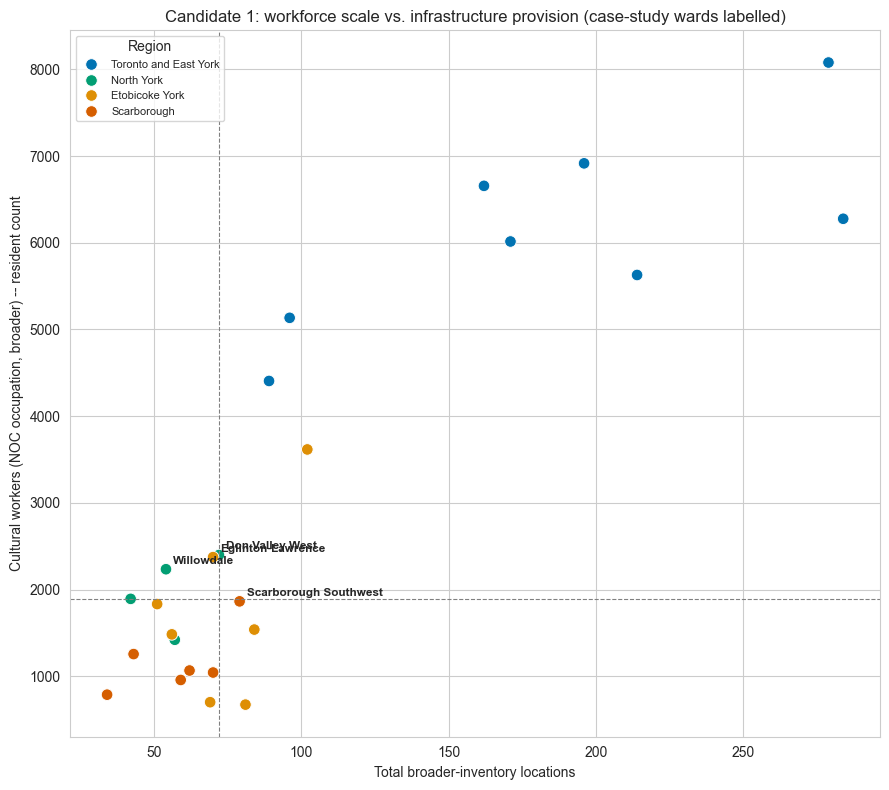

In [34]:
# --- candidate 1: quadrant (workforce scale vs. infrastructure provision), candidates labelled ---
fig, ax = plt.subplots(figsize=(9, 8))
sns.scatterplot(data=compare, x="n_locations", y=f"{WORKFORCE_MEASURE}_count", hue="region", palette=REGION_COLORS, s=70, ax=ax)
ax.axhline(compare[f"{WORKFORCE_MEASURE}_count"].median(), color="gray", linestyle="--", linewidth=0.8)
ax.axvline(compare["n_locations"].median(), color="gray", linestyle="--", linewidth=0.8)
for w in CASE_STUDY_WARDS:
    r = compare.set_index("ward_name").loc[w]
    ax.annotate(w, (r["n_locations"], r[f"{WORKFORCE_MEASURE}_count"]), fontsize=8.5, fontweight="bold",
                xytext=(5, 4), textcoords="offset points")
ax.set_xlabel("Total broader-inventory locations")
ax.set_ylabel(f"{NOC_NAICS_LABELS[WORKFORCE_MEASURE]} -- resident count")
ax.set_title("Candidate 1: workforce scale vs. infrastructure provision (case-study wards labelled)")
ax.legend(loc="upper left", fontsize=8, title="Region")
plt.tight_layout()
plt.show()

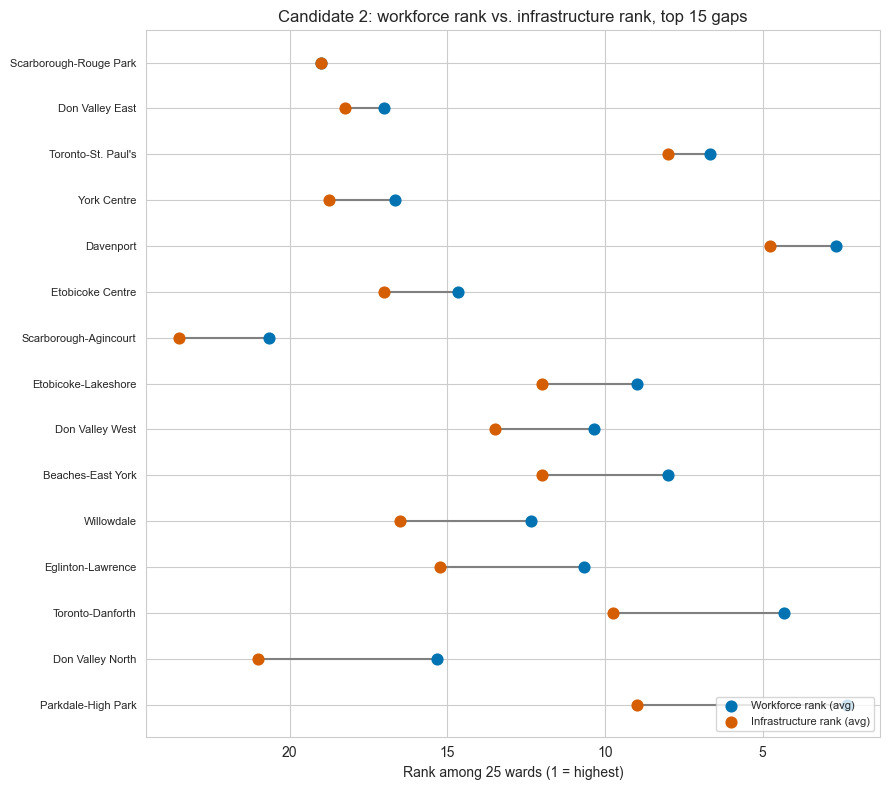

In [35]:
# --- candidate 2: dumbbell / rank-gap chart -----------------------------------------------
plot_rg = rank_gap.sort_values("rank_gap", ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 8))
y = np.arange(len(plot_rg))
ax.hlines(y, plot_rg["avg_infra_rank"], plot_rg["avg_workforce_rank"], color="gray", linewidth=1.5, zorder=1)
ax.scatter(plot_rg["avg_workforce_rank"], y, color=PALETTE[0], s=60, label="Workforce rank (avg)", zorder=2)
ax.scatter(plot_rg["avg_infra_rank"], y, color=PALETTE[3], s=60, label="Infrastructure rank (avg)", zorder=2)
ax.set_yticks(y)
ax.set_yticklabels(plot_rg["ward_name"], fontsize=8)
ax.invert_xaxis()
ax.set_xlabel("Rank among 25 wards (1 = highest)")
ax.set_title("Candidate 2: workforce rank vs. infrastructure rank, top 15 gaps")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

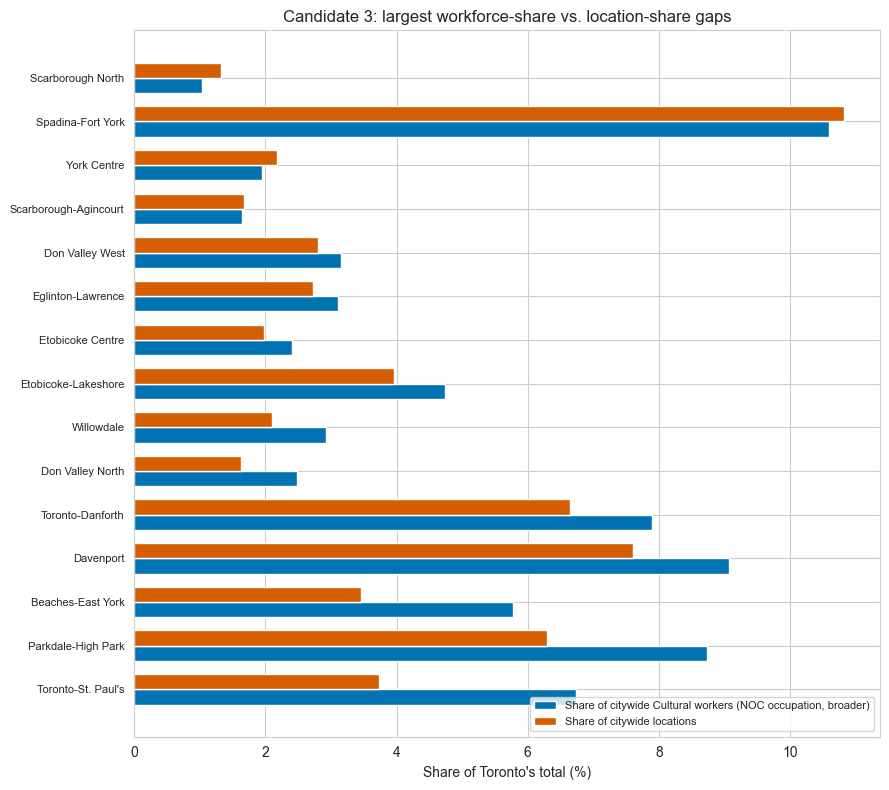

In [36]:
# --- candidate 3: paired citywide-share bars (workforce share vs. locations share) -------
plot_df3 = compare.sort_values("share_gap", ascending=False).head(15)
fig, ax = plt.subplots(figsize=(9, 8))
y = np.arange(len(plot_df3))
ax.barh(y, plot_df3["workforce_citywide_share"] * 100, height=0.35, color=PALETTE[0], label=f"Share of citywide {NOC_NAICS_LABELS[WORKFORCE_MEASURE]}")
ax.barh(y + 0.35, plot_df3["locations_citywide_share"] * 100, height=0.35, color=PALETTE[3], label="Share of citywide locations")
ax.set_yticks(y + 0.175)
ax.set_yticklabels(plot_df3["ward_name"], fontsize=8)
ax.set_xlabel("Share of Toronto's total (%)")
ax.set_title("Candidate 3: largest workforce-share vs. location-share gaps")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

**Assessment of the three candidates:**

- **Candidate 1 (quadrant scatter)** answers "which wards combine workforce scale with limited
  infrastructure" directly and stays interpretable with only a median reference line (no
  arbitrary threshold beyond "above/below the middle of 25 wards"). It does overstate precision
  slightly at the edges (wards just above/below the median line look categorically different
  but may be close in absolute terms) -- worth a caption noting this.
- **Candidate 2 (rank-gap dumbbell)** is the most information-dense (shows both ranks and the
  gap at once) but requires slightly more explanation for a non-technical audience ("rank" is
  less intuitive than a raw count or share).
- **Candidate 3 (paired citywide-share bars)** is the easiest for a lay reader (two bars, same
  units, same wards) and translates directly into the "X% of workforce but Y% of locations"
  councillor-facing sentence -- but it only shows citywide share, not absolute scale, so a very
  small ward could show a "gap" that is not large in raw numbers.

**Primary recommendation:** Candidate 3 (paired citywide-share bars) for the TAC-board-facing
citywide framing (it maps directly onto the "share of people vs. share of infrastructure"
language used throughout this notebook); Candidate 1 (quadrant) as the best *ward-identification*
tool to pair with it, since it shows absolute scale.

## 12. Story recommendations

### 1. Strongest refined thesis

> **"The cultural workforce is already present in specific, named parts of Toronto beyond
> downtown -- the question is whether local infrastructure and funding intensity reflect it."**

Of the three candidate story-language options in the brief, this is the best-supported: it
does not overclaim (it does not say infrastructure is *absent*, only that it may not
*reflect* the workforce), and it correctly scopes the claim to specific wards rather than
suburban Toronto broadly. **"Artists do not live only downtown"** is also well-supported (as a
count-level fact) and pairs naturally as the opening framing; **"some suburban wards already
contain the people needed"** is true only for a **short, named list** (Willowdale, Don Valley
North, and secondarily Eglinton-Lawrence and Don Valley West) -- not suburban Toronto in
general, consistent with the earlier notebook's own finding that workforce and infrastructure
are positively correlated citywide.

### 2. Strongest primary visual
**Candidate 3, the paired citywide-share bars** (Section 11): "share of Toronto's cultural
workforce" vs. "share of Toronto's cultural locations," one pair of bars per ward, sorted by
the gap. It translates directly into the councillor-facing sentence structure used throughout
this notebook and needs no rank or percentile explanation.

### 3. Supporting visuals
- **Candidate 1, the labelled quadrant scatter** (Section 5/11): workforce scale vs.
  infrastructure provision, with the four case-study wards labelled -- the best *ward-
  identification* tool, since it shows absolute scale, not just share.
- **The count-vs-percentage small multiples** (Section 3): shows the "artists live everywhere
  (count) vs. concentrated downtown (percentage/share)" duality directly, heading off the
  most likely misreading of the headline stat.
- **The Scarborough Southwest before/after panel** (built from Section 4 + Section 8's
  dossier: 1 activity-sample venue vs. 79 broader-inventory locations) -- the clearest single
  illustration of why the broader inventory matters.

### 4. Preferred measure for "artists"
**`labour_creatives`** (NOC occupation-based) -- primary, because occupation is the more
direct definitional match for "artist" than industry classification. **`labour_independent_
artists`** (NAICS industry) is the recommended secondary/complementary lens specifically for a
self-employed/freelance-artist framing.

### 5. Preferred measure for the broader "cultural workforce"
**`labour_cultural_workers`** (NOC occupation, broader) -- stays comparable to the preferred
artists measure (both occupation-based) while capturing the wider cultural-sector workforce.

### 6. Wards most consistently showing workforce/infrastructure mismatch
**Willowdale and Don Valley North** (flagged by all 3 independent Section 5 methods against
the broader inventory); **Eglinton-Lawrence and Don Valley West** as secondary candidates
(2 of 3 methods). **Scarborough Southwest does not qualify** as a robust mismatch ward against
the broader inventory (see item 10).

### 7. Strongest suburban case study
**Don Valley West** -- the cleanest version of the pattern: a meaningful, above-regional-
average cultural workforce, a thin activity-sample footprint (2 of 105 venues), and a
near-total (99.8%) outside-ward activity share at short, plausible distances (weighted median
4.5 km).

### 8. Strongest Scarborough example, if one exists
**None of the six Scarborough wards is a robust workforce/infrastructure mismatch case** in
this analysis -- a genuine, reportable difference from Story 1's Scarborough-internal *venue-
reach* network. The one Scarborough ward that does appear, **Scarborough Southwest**, earns
its place as the "broader inventory changes the story" case study (item 10), not as a
workforce-mismatch example. A councillor-facing Scarborough angle for *this* story should lead
with that limitation rather than force a mismatch narrative Scarborough does not support here.

### 9. What the mobility data adds to the workforce story
Concrete, named destination wards and venues for each case-study ward's residents (e.g. Don
Valley West's residents' recorded activity concentrates on Willowdale, University-Rosedale and
Toronto Centre), plausible short-to-moderate travel distances (4.5-10.0 km weighted medians
across the four case wards) that neither confirm nor deny adequacy of local access, and an
independent corroboration that Scarborough Southwest's residents travel meaningfully farther
(10.0 km) and toward downtown specifically -- consistent with it *not* having a nearby
suburban alternative the way the other three case wards do.

### 10. What the broader inventory changes relative to the earlier 105-venue analysis
It **overturns** Scarborough Southwest's identification as a workforce/infrastructure mismatch
ward: the 105-venue sample shows only 1 venue there, but the broader inventory shows 79
locations -- the second-most of our four case wards. It also **confirms** the earlier
notebook's citywide positive workforce-infrastructure correlation at larger scale (rho=0.72-
0.80 across several pairings here, consistent with the 105-venue-based rho=0.61-0.67 found in
Story 1), meaning the general "workforce and infrastructure track each other citywide" finding
is not an artifact of the smaller sample.

### 11. Housing, demographic, or funding results strong enough to include
- **Median income vs. artist concentration** (rho=0.83) and **vs. infrastructure provision
  per resident** (rho=0.60) -- both strong, stable, but cutting *against* a simple "under-
  served" narrative: wealthier wards have both more artists and more infrastructure per
  resident.
- **Population density vs. cultural-worker concentration** (rho=0.75) -- plausibly reflecting
  general downtown residential density patterns.
- **Visible-minority share vs. concentration**, all five measures (rho -0.81 to -0.87,
  p<0.001, not primarily a downtown/suburban composition artifact but tightly entangled with
  income) -- real and worth naming, but only with its income confound attached and never as a
  standalone headline (per the brief's explicit instruction).
- **Regional high-frequency-funding intensity gap** (Section 6/10): downtown over-supplied,
  all three suburban regions under-supplied, relative to workforce share.

### 12. Findings to omit
- Shelter-cost burden vs. independent-artist concentration (not significant).
- Median age, non-citizen share vs. cultural-worker concentration (not significant).
- Transit-commute and long-commute share vs. outside-ward activity (not significant).
- Population density vs. workforce/infrastructure rank gap (not significant).
- Arts-major population vs. free-programming availability (not significant).
- 105-venue-sample TAC-funded-operator/resident/programming flags vs. destination-ward
  workforce (too few non-missing values per ward, inconsistent direction, not a defensible
  comparison without funding amounts).
- The "counts reach farther into suburbs than percentages" pattern as a general claim (it is
  real but narrow -- one clear example, not a citywide phenomenon; see Section 3).

### Preliminary story sequence (4-6 sections, TAC board + councillor dual audience)

1. **Opening claim:** "Toronto's cultural workforce doesn't live only downtown" -- lead with
   the count-based small multiples (Section 3), immediately followed by the concentration
   caveat (55-74% of the workforce lives in "Toronto and East York" wards, which hold only
   32.5% of the population) so the claim isn't overstated.
2. **The citywide relationship, honestly stated:** workforce and infrastructure track each
   other citywide (rho=0.72-0.80) -- so this is a story about specific exceptions, not a
   general shortfall. Use the paired citywide-share bars (primary visual) here.
3. **Naming the exceptions:** Willowdale, Don Valley North, Eglinton-Lawrence, Don Valley
   West -- the quadrant scatter with these four labelled, plus the councillor-facing sentence
   template from Section 8's dossiers.
4. **Case study: Scarborough Southwest and the value of the broader inventory** -- the
   105-venue-sample-vs-79-location contrast, explicitly framed as "check your assumptions
   before naming a ward underserved."
5. **What this means for funding intensity, regionally:** the high-frequency-funding gap
   (downtown over-supplied, all three suburban regions under-supplied relative to workforce
   share) -- the one funding finding strong enough to carry to the TAC board.
6. **Caveats and what's still open:** ecological interpretation, sample vs. inventory vs.
   mobility-data distinctions, the income/visible-minority entanglement named responsibly, and
   the additional-evidence list below.

### Visual specification table

| Visual | Question answered | Form | Variables | Annotation | Why preferred | Role |
|---|---|---|---|---|---|---|
| Paired citywide-share bars | How does my ward's workforce share compare to its infrastructure share? | Grouped horizontal bar | `workforce_citywide_share`, `locations_citywide_share` | sorted by gap | Same units, same wards, maps directly to councillor sentence | Headline |
| Labelled quadrant scatter | Which wards combine workforce scale with limited infrastructure? | Scatter with median lines | `n_locations`, `{WORKFORCE_MEASURE}_count`, case-study wards labelled | median reference lines | Shows absolute scale, avoids a composite score | Supporting |
| Count-vs-percentage small multiples | Does "workforce lives everywhere" hold by count, by percentage, or both? | Small multiples, 5 panels | count and pct per measure | none needed | Prevents the most likely misreading of the headline | Supporting |
| Sample-vs-inventory before/after | Does the 105-venue sample distort a ward's infrastructure picture? | Paired bar, 1 ward at a time | `n_activity_sample_venues`, `n_locations` | ward name | Directly shows the broader inventory's value | Case-study |
| Rank-gap dumbbell | Which wards have the largest workforce-rank-vs-infrastructure-rank gap? | Dumbbell/lollipop | `avg_workforce_rank`, `avg_infra_rank` | top 15 gaps | Densest single view of the mismatch ranking | Discussion |

### Findings ready for story development
- Toronto and East York wards hold 32.5% of the population but 55.4-74.4% of the cultural
  workforce depending on the definition -- a large, consistent downtown over-index.
- Workforce and infrastructure provision are positively correlated citywide (rho=0.72-0.80),
  confirming the earlier notebook's finding at the broader-inventory scale -- this is a
  specific-exceptions story, not a general shortfall.
- Willowdale and Don Valley North are the most robust workforce/infrastructure mismatch
  wards against the broader inventory; Eglinton-Lawrence and Don Valley West are secondary.
- Scarborough Southwest's earlier "artist-heavy, venue-poor" label does not survive against
  the broader inventory (79 locations vs. 1 activity-sample venue) -- a clear instance of the
  broader inventory overturning a 105-venue-sample-based finding.
- All three suburban regions trail their workforce share specifically on high-frequency
  funded activity, while downtown leads its own workforce share on that same measure.
- Median income and population density are the strongest, most stable correlates of
  workforce concentration in this dataset (rho=0.75-0.85).

### Findings that need qualification
- The visible-minority-vs-concentration relationship (rho -0.81 to -0.87) is real and stable
  but is tightly entangled with income and must never be presented without that confound
  named, nor as a statement about who is or is not an artist.
- The "counts reach farther into the suburbs than percentages" pattern is real for
  `labour_cultural_workers` in Don Valley North specifically, but is not a citywide pattern
  across the other four measures.
- All case-study venue-use figures describe the wider resident population of each ward, not
  cultural workers specifically -- the mobility data cannot identify who is a cultural worker.
- Willowdale's within-ward concentration (94.5%) is likely substantially a single-venue
  (Meridian Arts Centre) effect, per Story 1; this notebook did not recompute a Willowdale-
  specific Meridian-excluded figure.

### Additional evidence needed
- **Funding amounts** (not just yes/no flags or ordinal frequency categories) to make any
  funding-equity claim defensible.
- **Venue-level capacity, discipline, and permanence** for the broader ~2,576-location
  inventory -- we currently know locations exist, not what they do or how much activity they
  support.
- **Artist surveys or interviews** to check whether residents in the case-study wards actually
  perceive an infrastructure gap, since this notebook's mismatch measures are entirely
  supply-side.
- **Workspace and rehearsal-space inventories**, distinct from public-facing venues, since a
  ward's cultural workforce may use spaces this dataset does not capture at all.
- **Employment-place data** (where cultural workers actually work, not just live) to
  complement this notebook's residence-based view.
- **Housing-cost and displacement histories** to responsibly investigate whether affordability
  is shaping *where* Toronto's cultural workforce can currently afford to live.